In [27]:
import pandas as pd
from datetime import datetime

### Cargar Datos

In [28]:
equipos  = pd.read_csv(r"C:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\Documents\Cosas\Cosas\Prueba tecnica Senior\Datos\historico_equipos.csv")
X  = pd.read_csv(r"C:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\Documents\Cosas\Cosas\Prueba tecnica Senior\Datos\X.csv")
Y  = pd.read_csv(r"C:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\Documents\Cosas\Cosas\Prueba tecnica Senior\Datos\Y.csv", sep = ";")
Z  = pd.read_csv(r"C:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\Documents\Cosas\Cosas\Prueba tecnica Senior\Datos\Z.csv")

### Compocisión de los datos

In [29]:
print(equipos.shape)
print(X .shape)
print(Y.shape)
print(Z.shape)

(3530, 6)
(9144, 2)
(4485, 2)
(3565, 2)


In [30]:
X

,Date,Price
0,2024-04-04,89.18
1,2024-04-03,89.35
2,2024-04-02,88.92
3,2024-04-01,87.42
4,2024-03-28,87.48
...,...,...
9139,1988-07-01,14.60
9140,1988-06-30,14.85
9141,1988-06-29,15.47
9142,1988-06-28,15.27


#### Analisis de las fechas

In [31]:
print(equipos["Date"].max(), equipos["Date"].min())
print(X["Date"].max(), X["Date"].min())
print(Y["Date"].max(), Y["Date"].min())
print(Z["Date"].max(), Z["Date"].min())

2023-08-31 2010-01-04
2024-04-04 1988-06-27
9/9/2022 1/1/2007
2023-08-31 2010-01-01


## Converitr las fechas en formato Date

In [32]:
equipos["Date"] = pd.to_datetime(equipos["Date"], format= "%Y-%m-%d" ).dt.date
X["Date"] = pd.to_datetime(X["Date"], format= "%Y-%m-%d").dt.date
Y["Date"] = pd.to_datetime(Y["Date"], format= "%d/%m/%Y").dt.date
Z["Date"] = pd.to_datetime(Z["Date"], format= "%Y-%m-%d" ).dt.date

In [33]:
print(equipos["Date"].max(), equipos["Date"].min())
print(X["Date"].max(), X["Date"].min())
print(Y["Date"].max(), Y["Date"].min())
print(Z["Date"].max(), Z["Date"].min())

2023-08-31 2010-01-04
2024-04-04 1988-06-27
2023-09-12 2006-07-11
2023-08-31 2010-01-01


In [34]:
print(equipos.columns)
print(X.columns)
print(Y.columns)
print(Z.columns)

Index(['Date', 'Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1',
       'Price_Equipo2'],
      dtype='object')
Index(['Date', 'Price'], dtype='object')
Index(['Date', 'Price'], dtype='object')
Index(['Price', 'Date'], dtype='object')


### Limpieza del texto

In [35]:
Y["Price"] = Y["Price"].str.replace(",", ".").astype(float)

In [36]:
equipos

,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.50,2225.25,434.73,931.73
1,2010-01-05,80.59,527.50,2246.50,449.97,968.56
2,2010-01-06,81.89,527.50,2302.50,444.48,960.51
3,2010-01-07,81.51,527.50,2306.50,440.90,960.14
4,2010-01-08,81.37,552.50,2261.25,448.82,949.55
...,...,...,...,...,...,...
3525,2023-08-25,84.48,554.00,2123.50,450.36,899.65
3526,2023-08-28,84.42,549.00,2116.25,469.03,933.20
3527,2023-08-29,85.49,545.33,2116.25,460.42,901.79
3528,2023-08-30,85.86,543.67,2140.25,464.80,945.40


In [37]:
X

,Date,Price
0,2024-04-04,89.18
1,2024-04-03,89.35
2,2024-04-02,88.92
3,2024-04-01,87.42
4,2024-03-28,87.48
...,...,...
9139,1988-07-01,14.60
9140,1988-06-30,14.85
9141,1988-06-29,15.47
9142,1988-06-28,15.27


In [38]:
Y

,Date,Price
0,2023-09-12,547.33
1,2023-09-11,546.00
2,2023-09-08,545.00
3,2023-09-07,550.00
4,2023-09-06,552.50
...,...,...
4480,2006-07-17,555.00
4481,2006-07-14,555.00
4482,2006-07-13,555.00
4483,2006-07-12,555.00


In [39]:
Z

,Price,Date
0,2225.25,2010-01-01
1,2225.25,2010-01-04
2,2246.50,2010-01-05
3,2302.50,2010-01-06
4,2306.50,2010-01-07
...,...,...
3560,2123.50,2023-08-25
3561,2116.25,2023-08-28
3562,2116.25,2023-08-29
3563,2140.25,2023-08-30


#### Join de las bases para corroborar los datos

In [40]:
df_merge = equipos.merge(X.rename(columns={"Price": "Price_X2"}), on= "Date", how = "left").merge(Y.rename(columns={"Price": "Price_Y2"}), on= "Date", how = "left").merge(Z.rename(columns={"Price": "Price_Z2"}), on= "Date", how = "left")

In [41]:
df_merge

,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2,Price_X2,Price_Y2,Price_Z2
0,2010-01-04,80.12,527.50,2225.25,434.73,931.73,80.12,527.50,2225.25
1,2010-01-05,80.59,527.50,2246.50,449.97,968.56,80.59,527.50,2246.50
2,2010-01-06,81.89,527.50,2302.50,444.48,960.51,81.89,527.50,2302.50
3,2010-01-07,81.51,527.50,2306.50,440.90,960.14,81.51,527.50,2306.50
4,2010-01-08,81.37,552.50,2261.25,448.82,949.55,81.37,552.50,2261.25
...,...,...,...,...,...,...,...,...,...
3525,2023-08-25,84.48,554.00,2123.50,450.36,899.65,84.48,554.00,2123.50
3526,2023-08-28,84.42,549.00,2116.25,469.03,933.20,84.42,549.00,2116.25
3527,2023-08-29,85.49,545.33,2116.25,460.42,901.79,85.49,545.33,2116.25
3528,2023-08-30,85.86,543.67,2140.25,464.80,945.40,85.86,543.67,2140.25


In [42]:
df_merge.columns

Index(['Date', 'Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1',
       'Price_Equipo2', 'Price_X2', 'Price_Y2', 'Price_Z2'],
      dtype='object')

#### Conteo de Nulos

In [43]:
df_merge.isnull().sum()

Date             0
Price_X          0
Price_Y          0
Price_Z          0
Price_Equipo1    0
Price_Equipo2    0
Price_X2         0
Price_Y2         0
Price_Z2         0
dtype: int64

### Hallar las diferencias entre las bases

In [44]:
df_merge['Var_X'] = df_merge['Price_X2'] - df_merge['Price_X']
df_merge['Var_Y'] = df_merge['Price_Y2'] - df_merge['Price_Y']
df_merge['Var_Z'] = df_merge['Price_Z2'] - df_merge['Price_Z']

In [45]:
df_merge.describe()

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2,Price_X2,Price_Y2,Price_Z2,Var_X,Var_Y,Var_Z
count,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.0,3530.0,3530.0
mean,78.091014,555.527108,2037.432073,460.036901,889.980408,78.091014,555.527108,2037.432073,0.0,0.0,0.0
std,25.186945,138.489003,373.140448,113.681273,170.042689,25.186945,138.489003,373.140448,0.0,0.0,0.0
min,19.330000,257.500000,1421.500000,208.340000,566.000000,19.330000,257.500000,1421.500000,0.0,0.0,0.0
25%,57.052500,482.500000,1767.250000,398.227500,777.702500,57.052500,482.500000,1767.250000,0.0,0.0,0.0
50%,75.400000,541.625000,1974.750000,451.250000,869.785000,75.400000,541.625000,1974.750000,0.0,0.0,0.0
75%,104.582500,620.000000,2235.937500,515.607500,979.122500,104.582500,620.000000,2235.937500,0.0,0.0,0.0
max,127.980000,1062.370000,3984.000000,855.320000,1703.960000,127.980000,1062.370000,3984.000000,0.0,0.0,0.0


Con este describe, corroboramos que tanto las base de "equipos" como las bases de las materias primas tienen la misma informacion, la diferencia esta en las temporalidades de todas las bases

In [46]:
df = equipos.copy()

*Las materias primas estan correlacionadas con los precios de los equipos, en especial el Price Y y Price X con el precio del equipo 1 y 2 
*El analisis de Correlaciones nos muestra una alta correlacion entre Price Z y Price Y, lo cual nos empieza a indicar multicolinealidad entre ambas
*Descartaremos multicolinealidad mediante regresiones

### Analisis de las Variables Ovjetivo a traves del tiempo

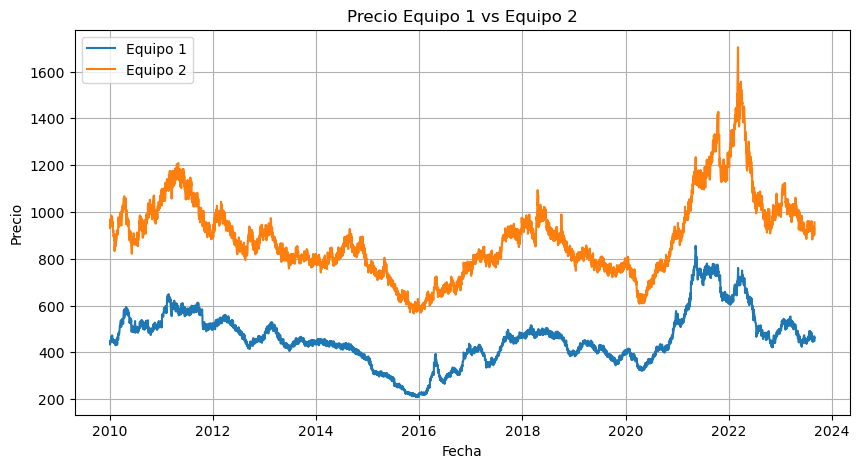

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegúrate de que la columna Date sea tipo datetime
df['Date'] = pd.to_datetime(df['Date'])

# Ordenar por fecha (por si acaso)
df = df.sort_values('Date')

# Crear la gráfica
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Price_Equipo1'], label='Equipo 1')
plt.plot(df['Date'], df['Price_Equipo2'], label='Equipo 2')

# Personalización
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.title('Precio Equipo 1 vs Equipo 2')
plt.legend()
plt.grid()

# Mostrar
plt.show()

Se evidencia una posible estacionalidad entre los precios del equipo 1 y 2.

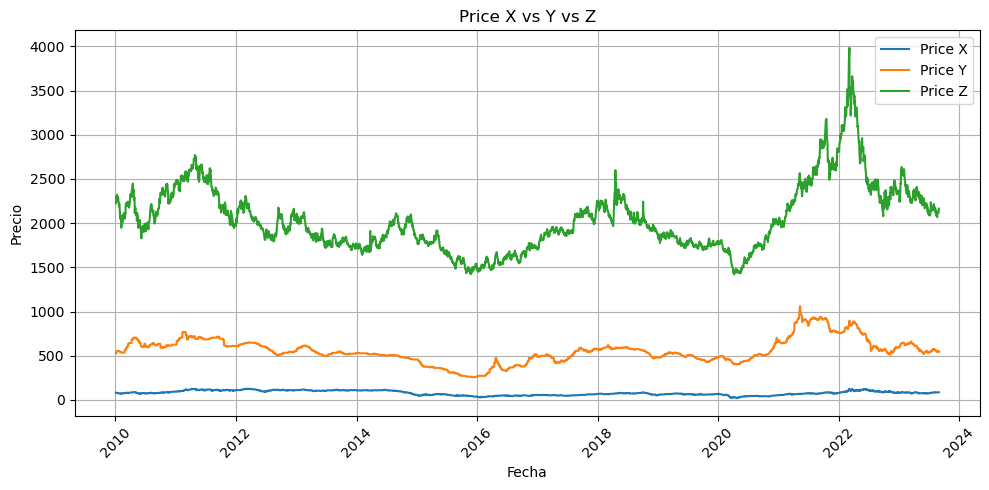

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegurar formato de fecha
df['Date'] = pd.to_datetime(df['Date'])

# Ordenar por fecha
df = df.sort_values('Date')

# Crear la gráfica
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Price_X'], label='Price X')
plt.plot(df['Date'], df['Price_Y'], label='Price Y')
plt.plot(df['Date'], df['Price_Z'], label='Price Z')

# Personalización
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.title('Price X vs Y vs Z')
plt.legend()
plt.grid()

# Mejorar visual
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar
plt.show()

*El comportamiento del Price Z y Y tienden a tener un comportamiento estacional, se realizaran pruebas de Dickey Fuller o Ruido Blanco para establecer si tienen estacionalidad.
*El Price Zs el mas elevado y se parece bastante al de los equipos, eso explicaria el por que estan tan correlacionadas.
*El Price Y tiene un comportamiento parecido al Price Z,  explicando la multiclinealidad.

### Analisis de Correlaciones

In [49]:
cols = ["Price_X", "Price_Y", "Price_Z", "Price_Equipo1", "Price_Equipo2"]

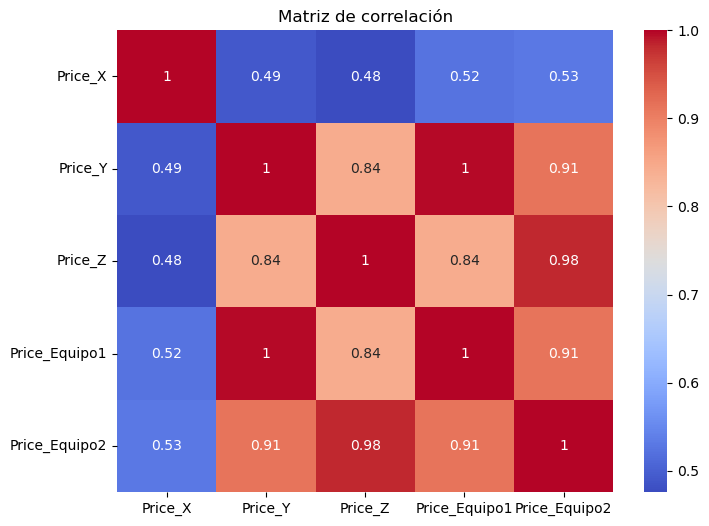

In [50]:
import seaborn as sns

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

*Las materias primas estan correlacionadas con los precios de los equipos, en especial el Price Y y Price X con el precio del equipo 1 y 2 
*El analisis de Correlaciones nos muestra una alta correlacion entre Price Z y Price Y, lo cual nos empieza a indicar multicolinealidad entre ambas
*Descartaremos multicolinealidad mediante regresiones

#### Regresion OLS con todas las materias primas

In [51]:
import statsmodels.api as sm

X2 = df[["Price_X", "Price_Y", "Price_Z"]]
X2 = sm.add_constant(X2)

y = df["Price_Equipo2"]

model = sm.OLS(y, X2).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo2   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 1.374e+05
Date:               lun, 20 abr. 2026   Prob (F-statistic):               0.00
Time:                        20:52:36   Log-Likelihood:                -14720.
No. Observations:                3530   AIC:                         2.945e+04
Df Residuals:                    3526   BIC:                         2.947e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2278      1.508      0.814      0.4

#### Regresion sin materia sin Price Y

In [52]:
X2 = df[["Price_X", "Price_Z"]]
X2 = sm.add_constant(X2)

y = df["Price_Equipo2"]

model = sm.OLS(y, X2).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo2   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                 5.854e+04
Date:               lun, 20 abr. 2026   Prob (F-statistic):               0.00
Time:                        20:52:36   Log-Likelihood:                -16905.
No. Observations:                3530   AIC:                         3.382e+04
Df Residuals:                    3527   BIC:                         3.383e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -29.3512      2.732    -10.742      0.0


Como se puede observar en los coefientes, Price Y está absorbiendo parte del efecto de Z, se elimina Y para evitar multicolinealidad.

In [53]:
features = ["Price_X", "Price_Z"]  # Y descartada
target1 = "Price_Equipo1"
target2 = "Price_Equipo2"

In [54]:
# df["X_forecast"] = df["Price_X"].rolling(window=3).mean()
# df["Z_forecast"] = df["Price_Z"].rolling(window=3).mean()

In [55]:
# df["Equipo1_model"] = 0.95 * df["Price_Z"]
# df["Equipo2_model"] = 0.7 * df["Price_X"] + 0.3 * df["Price_Z"]

### Estacionalidad

In [56]:
import pandas as pd

# Asegurar formato correcto
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Index temporal (clave para ARIMA/SARIMA)
df = df.set_index("Date")

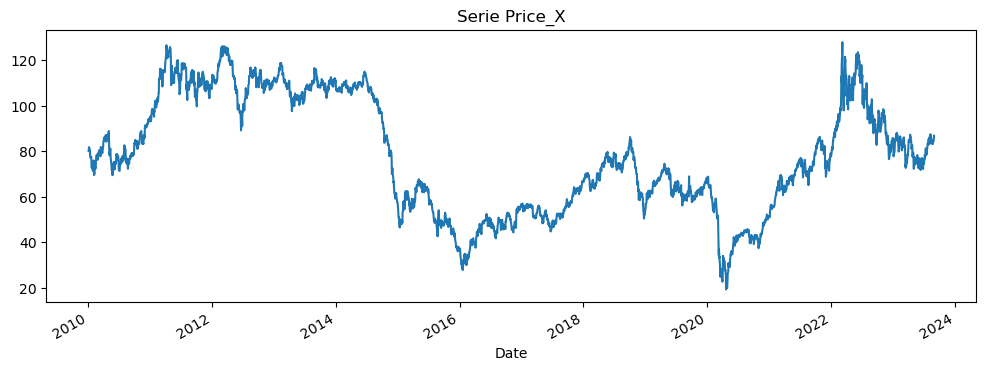

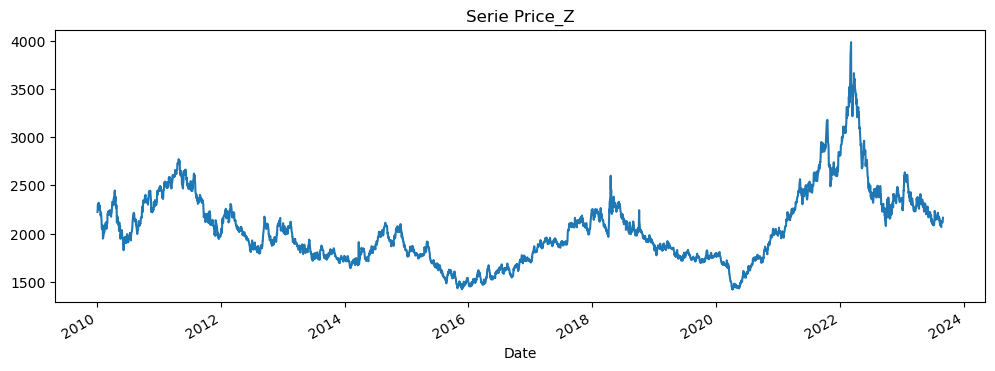

In [57]:
import matplotlib.pyplot as plt

df["Price_X"].plot(figsize=(12,4), title="Serie Price_X")
plt.show()

df["Price_Z"].plot(figsize=(12,4), title="Serie Price_Z")
plt.show()

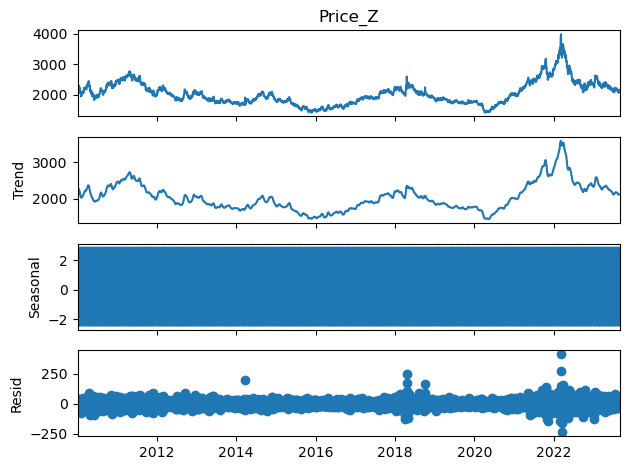

In [58]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ejemplo con Z
decomp = seasonal_decompose(df["Price_Z"], model='additive', period=12)

decomp.plot()
plt.show()

In [59]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"ADF Test {name}")
    print("p-value:", result[1])

adf_test(df["Price_X"], "X")
adf_test(df["Price_Z"], "Z")

ADF Test X
p-value: 0.42843847586600803
ADF Test Z
p-value: 0.20519131055447198


In [60]:
df["X_diff"] = df["Price_X"].diff()
df["Z_diff"] = df["Price_Z"].diff()

In [61]:
adf_test(df["X_diff"].dropna(), "X diff")
adf_test(df["Z_diff"].dropna(), "Z diff")

ADF Test X diff
p-value: 0.0
ADF Test Z diff
p-value: 2.723942677234721e-27


Se realizó la prueba de Dickey-Fuller aumentada (ADF) para evaluar la estacionariedad de las series de precios de las materias primas. Los resultados mostraron p-values superiores a 0.05, indicando no estacionariedad. En consecuencia, se aplicó una diferenciación de primer orden (d=1) para estabilizar las series antes de ajustar modelos ARIMA/SARIMA.

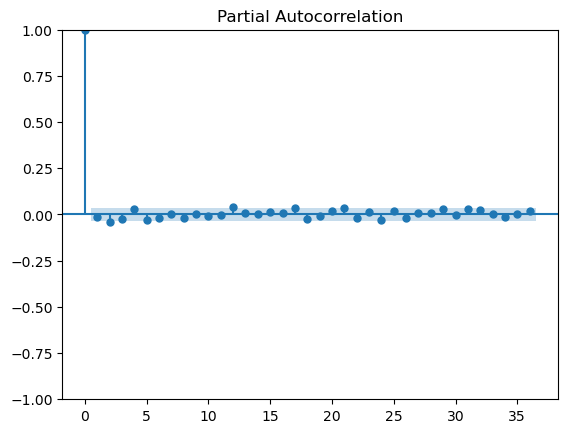

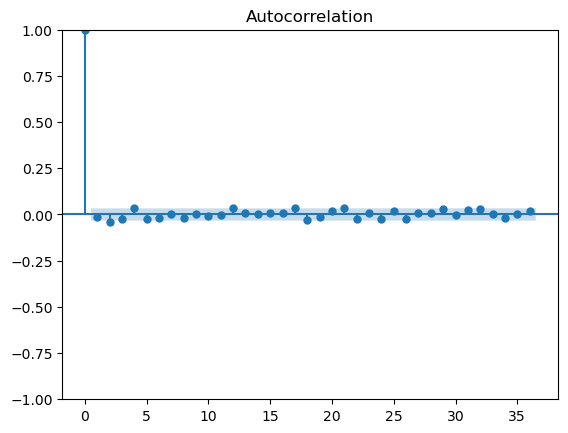

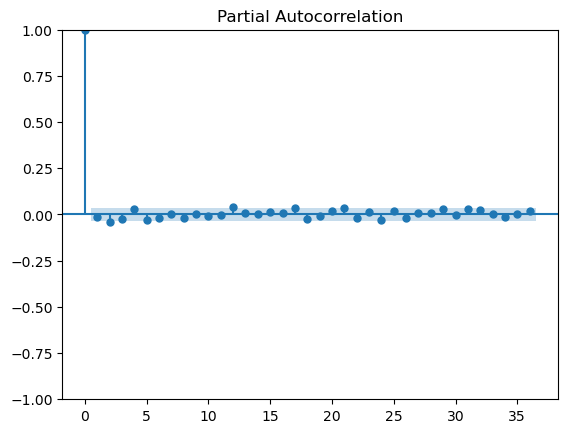

In [62]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df["X_diff"].dropna())
plot_pacf(df["X_diff"].dropna())

Las gráficas ACF y PACF muestran la diferenciación, la serie no presenta autocorrelaciones significativas, lo que indica estacionariedad. Esto sugiere que la dinámica de la serie puede ser capturada con modelos de bajo orden. Se optó por un SARIMA(1,1,1) con componente estacional para capturar posibles patrones débiles y estacionales, logrando un desempeño predictivo alto.

#### Modelo SARIMAX

In [63]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ajusta órdenes según análisis (ejemplo base)
model_X = SARIMAX(df["Price_X"], order=(1,1,1), seasonal_order=(1,1,1,12))
results_X = model_X.fit()

print(results_X.summary())

c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameter

                                     SARIMAX Results                                      
Dep. Variable:                            Price_X   No. Observations:                 3530
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -6592.427
Date:                           lun, 20 abr. 2026   AIC                          13194.853
Time:                                    20:52:45   BIC                          13225.680
Sample:                                         0   HQIC                         13205.852
                                           - 3530                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7560      0.139      5.454      0.000       0.484       1.028
ma.L1         -0.7805      0.132   

In [64]:
model_Z = SARIMAX(df["Price_Z"], order=(1,1,1), seasonal_order=(1,1,1,12))
results_Z = model_Z.fit()

print(results_Z.summary())

c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                            Price_Z   No. Observations:                 3530
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood              -17110.497
Date:                           lun, 20 abr. 2026   AIC                          34230.993
Time:                                    20:52:50   BIC                          34261.820
Sample:                                         0   HQIC                         34241.992
                                           - 3530                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5141      0.106     -4.827      0.000      -0.723      -0.305
ma.L1          0.4472      0.111   

Proyectamos la serie a 30 periodos en el futuro ( 1 mes), debido a que los datos son diario, se manejo esta temporalidad para evaluar el nivel de prediccion de las materias primas.

In [65]:
steps = 30

forecast_X = results_X.get_forecast(steps=steps)
forecast_Z = results_Z.get_forecast(steps=steps)

X_pred = forecast_X.predicted_mean
Z_pred = forecast_Z.predicted_mean

c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [66]:
conf_X = forecast_X.conf_int()
conf_Z = forecast_Z.conf_int()

In [67]:
pred_x_conso = pd.concat([conf_X,X_pred], axis = 1).reset_index(drop = True)

#### intervalos de confianza del forestas SARIMAX

In [68]:
pred_x_conso

,lower Price_X,upper Price_X,predicted_mean
0,83.435610,89.568716,86.502163
1,82.219386,90.787447,86.503417
2,81.398040,91.783780,86.590910
3,80.519488,92.407129,86.463308
4,79.840891,93.032653,86.436772
5,79.044770,93.403420,86.224095
6,78.642404,94.066419,86.354412
7,78.222221,94.633035,86.427628
8,77.938004,95.272719,86.605362
9,77.520657,95.727562,86.624109


In [69]:
X

,Date,Price
0,2024-04-04,89.18
1,2024-04-03,89.35
2,2024-04-02,88.92
3,2024-04-01,87.42
4,2024-03-28,87.48
...,...,...
9139,1988-07-01,14.60
9140,1988-06-30,14.85
9141,1988-06-29,15.47
9142,1988-06-28,15.27


In [70]:
real = X[X["Date"] >= equipos["Date"].max()].head(30)

In [71]:
pd.concat([real,X_pred.reset_index(drop=True)], axis = 1)

,Date,Price,predicted_mean
0,2024-04-04,89.18,86.502163
1,2024-04-03,89.35,86.503417
2,2024-04-02,88.92,86.590910
3,2024-04-01,87.42,86.463308
4,2024-03-28,87.48,86.436772
5,2024-03-27,86.09,86.224095
6,2024-03-26,86.25,86.354412
7,2024-03-25,86.75,86.427628
8,2024-03-22,85.43,86.605362
9,2024-03-21,85.78,86.624109


In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error


y_true = real["Price"]
y_pred = X_pred

# MSE
mse = mean_squared_error(y_true, y_pred)

# MAPE
mape = mean_absolute_percentage_error(y_true, y_pred)

print("MSE:", mse)
print("MAPE:", mape)

MSE: 7.950546914280651
MAPE: 0.028437875245016894


* Price X tenia periodos despues de la fecha de la base de equipo, esta ventaja la use para verificar que el modelo SARIMAX, estuviera prediciendo bien.
* El modelo presenta un muy buen desempeño. El MSE (7.95) indica que los errores son bajos y no hay grandes desviaciones, mientras que el MAPE (2.84%) muestra que, en promedio, el error es menor al 3%, lo cual se considera excelente.
* En consecuencia, el modelo tiene un alto poder predictivo y es confiable para proyectar el precio de X.

### Promedio Movil

Creamos variables de promedios móviles con el objetivo de mejorar la capacidad predictiva de los modelos para los equipos 1 y 2. Para ello, utilizamos diferentes ventanas de tiempo, buscando capturar patrones y tendencias que aportaran mayor información y robustez a las predicciones.

In [73]:
df["X_prom_3"] = df["Price_X"].rolling(window=3).mean()
df["Z_prom_3"] = df["Price_Z"].rolling(window=3).mean()
df["X_prom_6"] = df["Price_X"].rolling(window=6).mean()
df["Z_prom_6"] = df["Price_Z"].rolling(window=6).mean()
df["X_prom_9"] = df["Price_X"].rolling(window=9).mean()
df["Z_prom_9"] = df["Price_Z"].rolling(window=9).mean()
df["X_prom_12"] = df["Price_X"].rolling(window=12).mean()
df["Z_prom_12"] = df["Price_Z"].rolling(window=12).mean()
df["X_prom_15"] = df["Price_X"].rolling(window=15).mean()
df["Z_prom_15"] = df["Price_Z"].rolling(window=15).mean()
df["X_prom_30"] = df["Price_X"].rolling(window=30).mean()
df["Z_prom_30"] = df["Price_Z"].rolling(window=30).mean()

In [74]:
df

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2,X_diff,Z_diff,X_prom_3,Z_prom_3,X_prom_6,Z_prom_6,X_prom_9,Z_prom_9,X_prom_12,Z_prom_12,X_prom_15,Z_prom_15,X_prom_30,Z_prom_30
Date,,,,,,,,,,,,,,,,,,,
2010-01-04,80.12,527.50,2225.25,434.73,931.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,80.59,527.50,2246.50,449.97,968.56,0.47,21.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,81.89,527.50,2302.50,444.48,960.51,1.30,56.00,80.866667,2258.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,81.51,527.50,2306.50,440.90,960.14,-0.38,4.00,81.330000,2285.166667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,81.37,552.50,2261.25,448.82,949.55,-0.14,-45.25,81.590000,2290.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-25,84.48,554.00,2123.50,450.36,899.65,1.12,4.25,83.683333,2123.833333,84.056667,2109.458333,84.088889,2106.805556,84.685000,2112.020833,85.018667,2121.133333,83.905333,2146.400000
2023-08-28,84.42,549.00,2116.25,469.03,933.20,-0.06,-7.25,84.086667,2119.666667,83.993333,2112.875000,84.036667,2110.250000,84.520000,2108.270833,84.957333,2117.033333,84.102667,2143.791667
2023-08-29,85.49,545.33,2116.25,460.42,901.79,1.07,0.00,84.796667,2118.666667,84.165000,2120.875000,84.263333,2113.305556,84.410000,2107.458333,84.912000,2115.283333,84.298000,2142.033333


### Precios Lag

Construimos variables rezagadas (lags) con el fin de evaluar si la información histórica de las variables podía aportar mayor capacidad predictiva a los modelos de los equipos 1 y 2. Para ello, incorporamos distintos rezagos en el tiempo, buscando capturar efectos diferidos y dependencias temporales que pudieran mejorar la precisión de las predicciones.

In [75]:
# Lags reales (valores pasados)
df["X_lag_1"] = df["Price_X"].shift(1)
df["X_lag_3"] = df["Price_X"].shift(3)
df["X_lag_6"] = df["Price_X"].shift(6)
df["X_lag_12"] = df["Price_X"].shift(12)
df["X_lag_15"] = df["Price_X"].shift(15)
df["X_lag_30"] = df["Price_X"].shift(30)
df["Z_lag_1"] = df["Price_Z"].shift(1)
df["Z_lag_3"] = df["Price_Z"].shift(3)
df["Z_lag_6"] = df["Price_Z"].shift(6)
df["Z_lag_12"] = df["Price_Z"].shift(12)
df["Z_lag_15"] = df["Price_Z"].shift(15)
df["Z_lag_30"] = df["Price_Z"].shift(30)

In [76]:
df

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2,X_diff,Z_diff,X_prom_3,Z_prom_3,X_prom_6,...,X_lag_6,X_lag_12,X_lag_15,X_lag_30,Z_lag_1,Z_lag_3,Z_lag_6,Z_lag_12,Z_lag_15,Z_lag_30
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,80.12,527.50,2225.25,434.73,931.73,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,80.59,527.50,2246.50,449.97,968.56,0.47,21.25,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2225.25,NaN,NaN,NaN,NaN,NaN
2010-01-06,81.89,527.50,2302.50,444.48,960.51,1.30,56.00,80.866667,2258.083333,NaN,...,NaN,NaN,NaN,NaN,2246.50,NaN,NaN,NaN,NaN,NaN
2010-01-07,81.51,527.50,2306.50,440.90,960.14,-0.38,4.00,81.330000,2285.166667,NaN,...,NaN,NaN,NaN,NaN,2302.50,2225.25,NaN,NaN,NaN,NaN
2010-01-08,81.37,552.50,2261.25,448.82,949.55,-0.14,-45.25,81.590000,2290.083333,NaN,...,NaN,NaN,NaN,NaN,2306.50,2246.50,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-25,84.48,554.00,2123.50,450.36,899.65,1.12,4.25,83.683333,2123.833333,84.056667,...,84.12,87.55,86.24,79.87,2119.25,2121.25,2130.50,2152.50,2165.00,2224.75
2023-08-28,84.42,549.00,2116.25,469.03,933.20,-0.06,-7.25,84.086667,2119.666667,83.993333,...,84.80,86.40,85.34,78.50,2123.50,2128.75,2095.75,2161.25,2177.75,2194.50
2023-08-29,85.49,545.33,2116.25,460.42,901.79,1.07,0.00,84.796667,2118.666667,84.165000,...,84.46,86.81,86.17,79.63,2116.25,2119.25,2068.25,2126.00,2142.50,2169.00


In [77]:
df.dropna()

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2,X_diff,Z_diff,X_prom_3,Z_prom_3,X_prom_6,...,X_lag_6,X_lag_12,X_lag_15,X_lag_30,Z_lag_1,Z_lag_3,Z_lag_6,Z_lag_12,Z_lag_15,Z_lag_30
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-15,72.51,535.00,2032.50,445.36,869.78,-0.39,28.25,72.820000,2016.333333,72.206667,...,69.59,72.13,73.69,80.12,2004.25,2022.25,1948.50,2125.75,2217.25,2225.25
2010-02-16,75.68,535.00,2050.50,434.38,904.22,3.17,18.00,73.696667,2029.083333,73.135000,...,70.11,71.46,73.29,80.59,2032.50,2012.25,1973.75,2061.25,2189.25,2246.50
2010-02-17,76.27,535.00,2094.50,431.69,877.95,0.59,44.00,74.820000,2059.166667,73.825000,...,72.13,73.11,72.24,81.89,2050.50,2004.25,2002.25,2046.25,2148.75,2302.50
2010-02-18,77.78,535.00,2076.50,455.50,892.05,1.51,-18.00,76.576667,2073.833333,74.698333,...,72.54,76.06,72.13,81.51,2094.50,2032.50,2022.25,2074.75,2125.75,2306.50
2010-02-19,78.19,535.00,2071.50,456.03,892.66,0.41,-5.00,77.413333,2080.833333,75.555000,...,73.05,75.92,71.46,81.37,2076.50,2050.50,2012.25,2086.25,2061.25,2261.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-25,84.48,554.00,2123.50,450.36,899.65,1.12,4.25,83.683333,2123.833333,84.056667,...,84.12,87.55,86.24,79.87,2119.25,2121.25,2130.50,2152.50,2165.00,2224.75
2023-08-28,84.42,549.00,2116.25,469.03,933.20,-0.06,-7.25,84.086667,2119.666667,83.993333,...,84.80,86.40,85.34,78.50,2123.50,2128.75,2095.75,2161.25,2177.75,2194.50
2023-08-29,85.49,545.33,2116.25,460.42,901.79,1.07,0.00,84.796667,2118.666667,84.165000,...,84.46,86.81,86.17,79.63,2116.25,2119.25,2068.25,2126.00,2142.50,2169.00


In [78]:
## Hallamos solo las Features con las que modelaremos
features = df.reset_index().drop(["Z_diff","X_diff","Date","Price_Y","Price_Equipo2", "Price_Equipo1"], axis=1).columns

In [81]:
features

Index(['Price_X', 'Price_Z', 'X_prom_3', 'Z_prom_3', 'X_prom_6', 'Z_prom_6',
       'X_prom_9', 'Z_prom_9', 'X_prom_12', 'Z_prom_12', 'X_prom_15',
       'Z_prom_15', 'X_prom_30', 'Z_prom_30', 'X_lag_1', 'X_lag_3', 'X_lag_6',
       'X_lag_12', 'X_lag_15', 'X_lag_30', 'Z_lag_1', 'Z_lag_3', 'Z_lag_6',
       'Z_lag_12', 'Z_lag_15', 'Z_lag_30'],
      dtype='object')

### Modelamiento

In [82]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Dataset sin NaN
df_ml = df

X = df_ml[features]

y1 = df_ml[target1]
y2 = df_ml[target2]

X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, shuffle=False)
_, _, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, shuffle=False)

# Modelo para Equipo 1
model1 = XGBRegressor()
model1.fit(X_train, y1_train)

# Modelo para Equipo 2
model2 = XGBRegressor()
model2.fit(X_train, y2_train)

# Predicciones
y1_pred = model1.predict(X_test)
y2_pred = model2.predict(X_test)

# Métricas
rmse1 = np.sqrt(mean_squared_error(y1_test, y1_pred))
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))

mape1 = mean_absolute_percentage_error(y1_test, y1_pred)
mape2 = mean_absolute_percentage_error(y2_test, y2_pred)

print("📊 RESULTADOS MODELO FINAL")
print("---------------------------------")
print(f"Equipo 1 -> RMSE: {rmse1:.4f} | MAPE: {mape1:.4%}")
print(f"Equipo 2 -> RMSE: {rmse2:.4f} | MAPE: {mape2:.4%}")

📊 RESULTADOS MODELO FINAL
---------------------------------
Equipo 1 -> RMSE: 141.1108 | MAPE: 17.8548%
Equipo 2 -> RMSE: 117.3028 | MAPE: 6.3640%


* El modelo final seleccionado utiliza el conjunto completo de variables, logrando un MAPE de 6.36% para el Equipo 2 y 17.85% para el Equipo 1, evidenciando un alto nivel de precisión y capacidad predictiva.
* Intente iterar condo diferentes tipo de combinacion de variables, pero los KPIS empeoraban bastante, por eso decidí dejar todas las variables
* Se Testeo solo con 20% de la base debido a la cantidad tan limitada de datos historicos para modelar

### Eleccion de variables modelo 1 (Precio Equipo 1)


🎯 Feature Importance (XGBoost):
       Feature  Importance
13  Z_prom_30    0.168090
5    Z_prom_6    0.151957
12  X_prom_30    0.148585
4    X_prom_6    0.108846
6    X_prom_9    0.100663
0     Price_X    0.091355
3    Z_prom_3    0.070073
7    Z_prom_9    0.029284
19   X_lag_30    0.022209
9   Z_prom_12    0.017928
10  X_prom_15    0.017503
11  Z_prom_15    0.014221
25   Z_lag_30    0.013830
1     Price_Z    0.013773
8   X_prom_12    0.009052
17   X_lag_12    0.004097
24   Z_lag_15    0.003175
14    X_lag_1    0.002917
22    Z_lag_6    0.002473
2    X_prom_3    0.002356


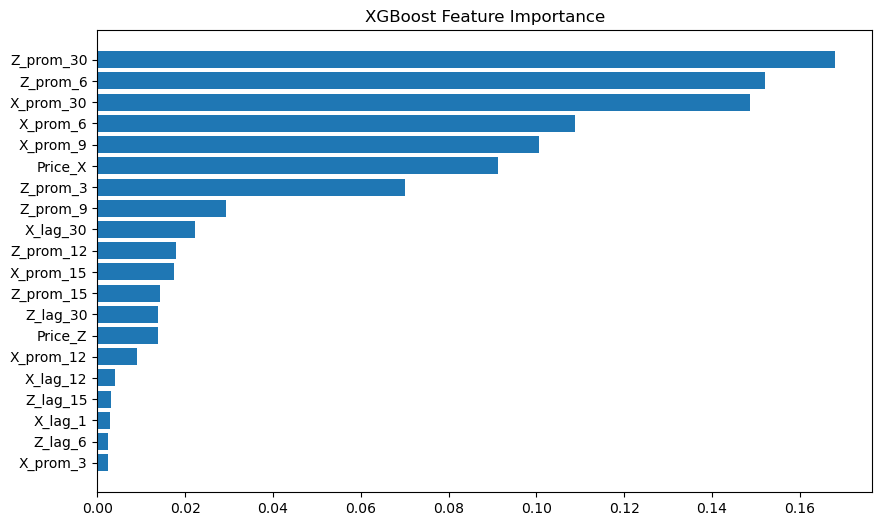

In [83]:
importances = model1.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)

print("\n🎯 Feature Importance (XGBoost):\n", importance_df)

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

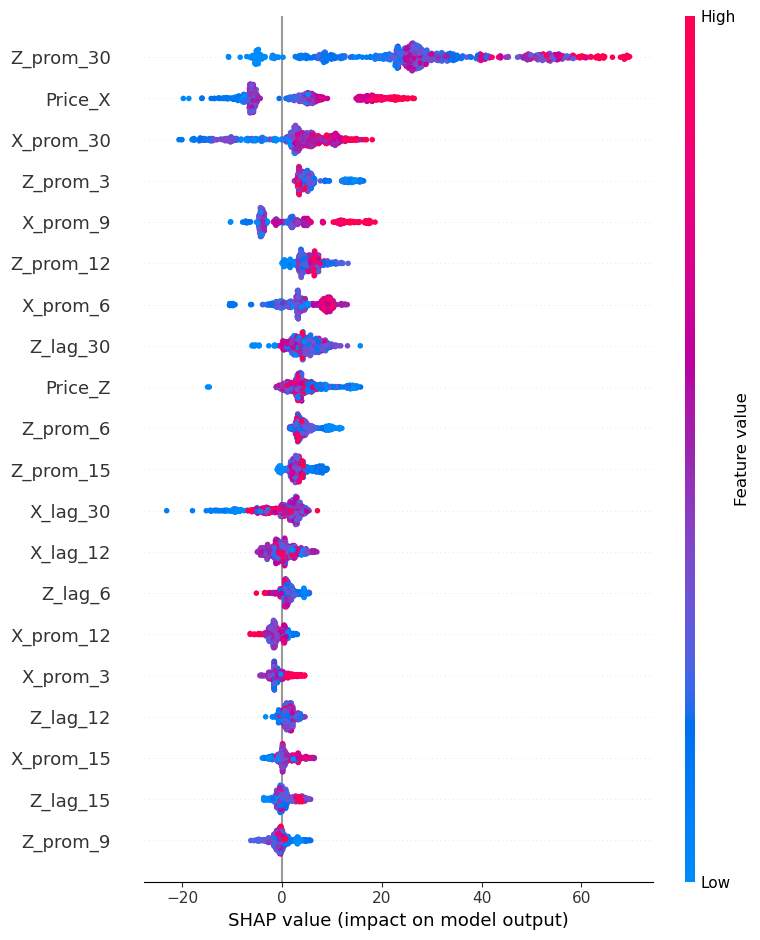

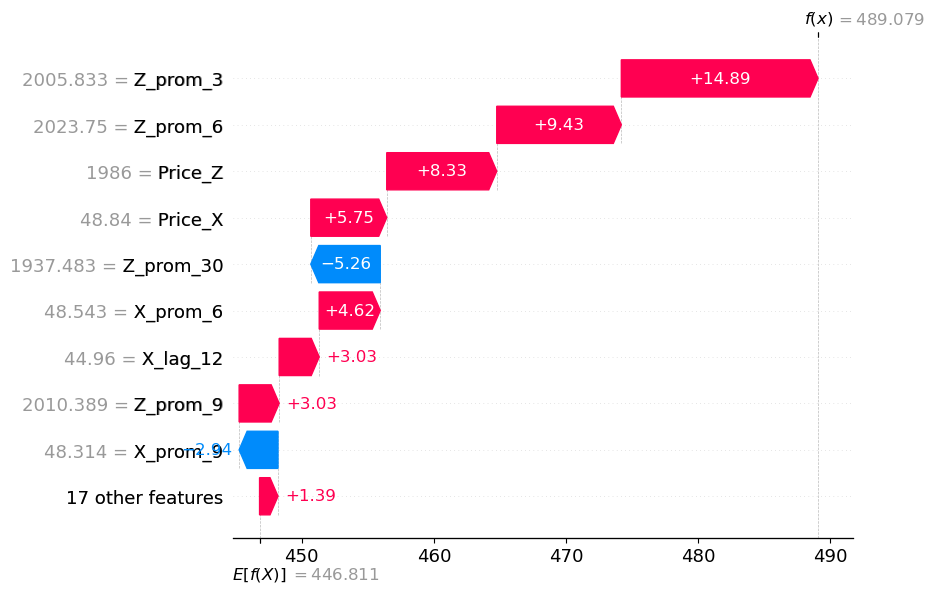

In [86]:
import shap 

explainer = shap.Explainer(model1, X_train)
shap_values = explainer(X_test)

# Resumen global
shap.summary_plot(shap_values, X_test)

# También puedes ver un resumen por instancia individual:
shap.plots.waterfall(shap_values[0])

In [87]:

# Convertir a array
shap_vals = shap_values.values

# Importancia global (media absoluta)
shap_importance = np.abs(shap_vals).mean(axis=0)

# Crear DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": shap_importance
})

# Ordenar
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Top 10
top12_model1 = feature_importance.head(12)

print(top12_model1)

      Feature  Importance
13  Z_prom_30   29.410772
0     Price_X    9.205234
12  X_prom_30    6.729336
3    Z_prom_3    5.864222
6    X_prom_9    5.201845
9   Z_prom_12    5.133158
4    X_prom_6    5.111293
25   Z_lag_30    4.702391
1     Price_Z    4.673797
5    Z_prom_6    4.515048
11  Z_prom_15    3.559486
19   X_lag_30    3.123561


### Eleccion de variables modelo 2 (Precio Equipo 2)


🎯 Feature Importance (XGBoost):
       Feature  Importance
5    Z_prom_6    0.448027
1     Price_Z    0.324698
3    Z_prom_3    0.091025
20    Z_lag_1    0.037656
7    Z_prom_9    0.016213
21    Z_lag_3    0.013812
10  X_prom_15    0.012653
4    X_prom_6    0.010207
6    X_prom_9    0.009821
13  Z_prom_30    0.008227
12  X_prom_30    0.005405
25   Z_lag_30    0.002855
19   X_lag_30    0.002584
17   X_lag_12    0.002111
14    X_lag_1    0.001778
22    Z_lag_6    0.001618
8   X_prom_12    0.001600
9   Z_prom_12    0.001583
11  Z_prom_15    0.001518
18   X_lag_15    0.001287


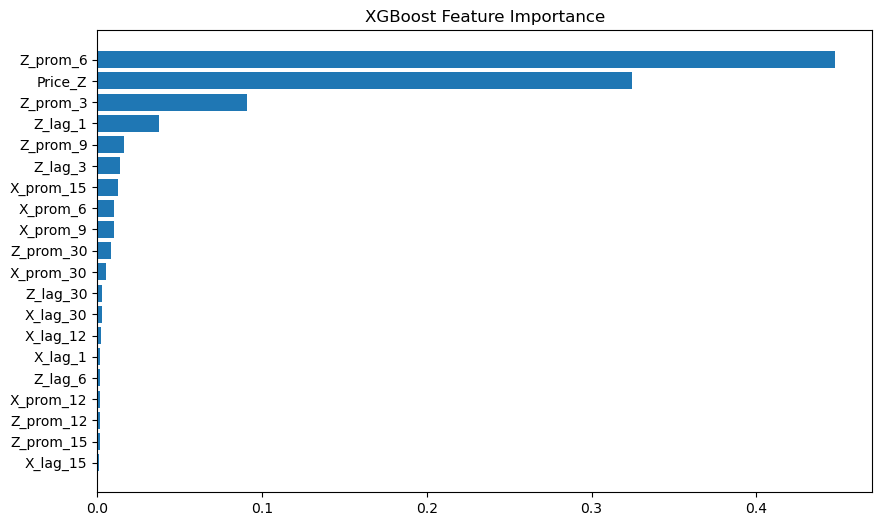

In [88]:
importances = model2.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)

print("\n🎯 Feature Importance (XGBoost):\n", importance_df)

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

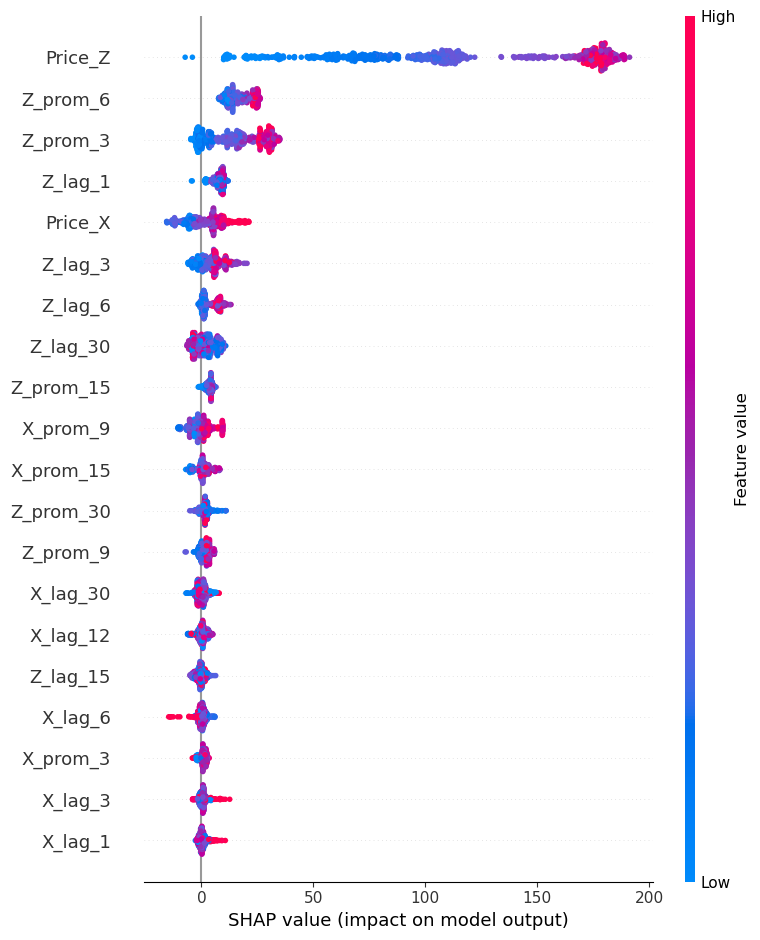

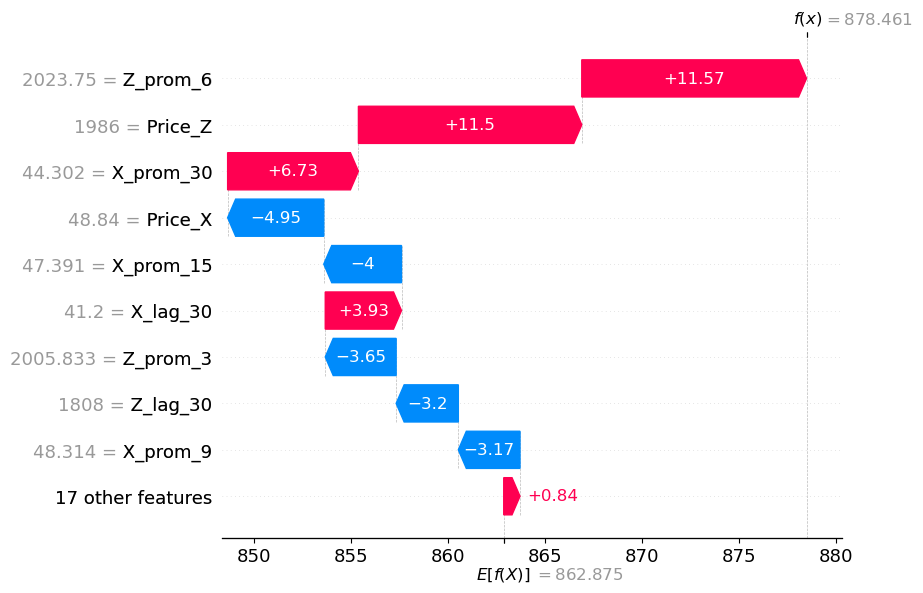

In [89]:
# ------------------------------
# 5. SHAP values
# ------------------------------
explainer = shap.Explainer(model2, X_train)
shap_values = explainer(X_test)

# Resumen global
shap.summary_plot(shap_values, X_test)

# También puedes ver un resumen por instancia individual:
shap.plots.waterfall(shap_values[0])

In [90]:
import numpy as np
import pandas as pd

# Convertir a array
shap_vals = shap_values.values

# Importancia global (media absoluta)
shap_importance = np.abs(shap_vals).mean(axis=0)

# Crear DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": shap_importance
})

# Ordenar
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Top 10
top10_model2 = feature_importance.head(10)

print(top10_model2)

      Feature  Importance
1     Price_Z  117.334269
5    Z_prom_6   16.908375
3    Z_prom_3   15.054872
20    Z_lag_1    7.816849
0     Price_X    6.458108
21    Z_lag_3    4.939049
22    Z_lag_6    3.777287
25   Z_lag_30    3.722854
11  Z_prom_15    3.564239
6    X_prom_9    3.019787


Se evaluaron modelos con selección de variables basada en SHAP; sin embargo, se observó una disminución en la precisión predictiva. Por ello, se optó por utilizar el modelo completo, el cual captura de mejor manera las relaciones no lineales entre las variables, logrando mejores métricas de desempeño.

##### Entrenar el modelo con el 100%

In [91]:
from xgboost import XGBRegressor

# Dataset limpio
df_ml = df

# Features (las mismas que usaste en el modelo final)
X = df_ml[features]

y1 = df_ml[target1]
y2 = df_ml[target2]

# Modelos finales
model1_final = XGBRegressor(random_state=42)
model2_final = XGBRegressor(random_state=42)

# Entrenamiento con TODO
model1_final.fit(X, y1)
model2_final.fit(X, y2)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

## Forecast

En esta seccion encontraremos los siguientes pronosticos
* Price X y Price Z
* Medias Moviles
* Variables rezagadas
* Todo esto con el fin de alimentar el modelo XGB y pronosticar los equipos 1 y 2

In [96]:
equipos

,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.50,2225.25,434.73,931.73
1,2010-01-05,80.59,527.50,2246.50,449.97,968.56
2,2010-01-06,81.89,527.50,2302.50,444.48,960.51
3,2010-01-07,81.51,527.50,2306.50,440.90,960.14
4,2010-01-08,81.37,552.50,2261.25,448.82,949.55
...,...,...,...,...,...,...
3525,2023-08-25,84.48,554.00,2123.50,450.36,899.65
3526,2023-08-28,84.42,549.00,2116.25,469.03,933.20
3527,2023-08-29,85.49,545.33,2116.25,460.42,901.79
3528,2023-08-30,85.86,543.67,2140.25,464.80,945.40


In [97]:
print(df.reset_index()["Date"].max() ,df.reset_index()["Date"].min()) 

2023-08-31 00:00:00 2010-01-04 00:00:00


In [98]:
last_date = df.reset_index()["Date"].max()

In [99]:
last_date

Timestamp('2023-08-31 00:00:00')

Pronosticamos 30 dias en el futuro

In [103]:
future_dates = pd.date_range(start=last_date, periods=30, freq='D')[1:]

In [104]:
forecast_df = pd.DataFrame({
    "Date": future_dates
}).reset_index(drop = True)

In [105]:
df_real_fsct = pd.concat([equipos.drop(["Price_Y"],axis=1),forecast_df], axis=0)

#### Modelos Sarima

Gracias al anlisis del modelo SARIMAX en pasos previos, logramos hallar los parametros que mejor se adaptan a las materias primas, de esta manera logramos pronosticarlo

In [106]:
model_X = SARIMAX(df["Price_X"], order=(1,1,1), seasonal_order=(1,1,1,12))
results_X = model_X.fit()
model_Z = SARIMAX(df["Price_Z"], order=(1,1,1), seasonal_order=(1,1,1,12))
results_Z = model_Z.fit()

c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameter

In [107]:
steps = 30

forecast_X = results_X.get_forecast(steps=steps)
forecast_Z = results_Z.get_forecast(steps=steps)

X_pred = forecast_X.predicted_mean.reset_index(drop = True)
Z_pred = forecast_Z.predicted_mean.reset_index(drop = True)

c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\Sebastian.garzon.LAPTOP-G9J39UDS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [108]:
conf_X = forecast_X.conf_int().reset_index(drop = True)
conf_Z = forecast_Z.conf_int().reset_index(drop = True)

In [109]:
pred_x_conso = pd.concat([forecast_df,conf_X,X_pred], axis = 1).reset_index(drop = True)
pred_z_conso = pd.concat([forecast_df,conf_Z,Z_pred], axis = 1).reset_index(drop = True)

In [110]:
df_x_forecast = pd.DataFrame({
    "Date": forecast_df["Date"],
    "X_mean": pred_x_conso["predicted_mean"],
    "X_lower": pred_x_conso["lower Price_X"],
    "X_upper": pred_x_conso["upper Price_X"]
})

df_z_forecast = pd.DataFrame({
    "Date": forecast_df["Date"],
    "Z_mean": pred_z_conso["predicted_mean"],
    "Z_lower": pred_z_conso["lower Price_Z"],
    "Z_upper": pred_z_conso["upper Price_Z"]
})

In [111]:
df

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2,X_diff,Z_diff,X_prom_3,Z_prom_3,X_prom_6,...,X_lag_6,X_lag_12,X_lag_15,X_lag_30,Z_lag_1,Z_lag_3,Z_lag_6,Z_lag_12,Z_lag_15,Z_lag_30
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,80.12,527.50,2225.25,434.73,931.73,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,80.59,527.50,2246.50,449.97,968.56,0.47,21.25,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2225.25,NaN,NaN,NaN,NaN,NaN
2010-01-06,81.89,527.50,2302.50,444.48,960.51,1.30,56.00,80.866667,2258.083333,NaN,...,NaN,NaN,NaN,NaN,2246.50,NaN,NaN,NaN,NaN,NaN
2010-01-07,81.51,527.50,2306.50,440.90,960.14,-0.38,4.00,81.330000,2285.166667,NaN,...,NaN,NaN,NaN,NaN,2302.50,2225.25,NaN,NaN,NaN,NaN
2010-01-08,81.37,552.50,2261.25,448.82,949.55,-0.14,-45.25,81.590000,2290.083333,NaN,...,NaN,NaN,NaN,NaN,2306.50,2246.50,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-25,84.48,554.00,2123.50,450.36,899.65,1.12,4.25,83.683333,2123.833333,84.056667,...,84.12,87.55,86.24,79.87,2119.25,2121.25,2130.50,2152.50,2165.00,2224.75
2023-08-28,84.42,549.00,2116.25,469.03,933.20,-0.06,-7.25,84.086667,2119.666667,83.993333,...,84.80,86.40,85.34,78.50,2123.50,2128.75,2095.75,2161.25,2177.75,2194.50
2023-08-29,85.49,545.33,2116.25,460.42,901.79,1.07,0.00,84.796667,2118.666667,84.165000,...,84.46,86.81,86.17,79.63,2116.25,2119.25,2068.25,2126.00,2142.50,2169.00


#### Pronostico Price X

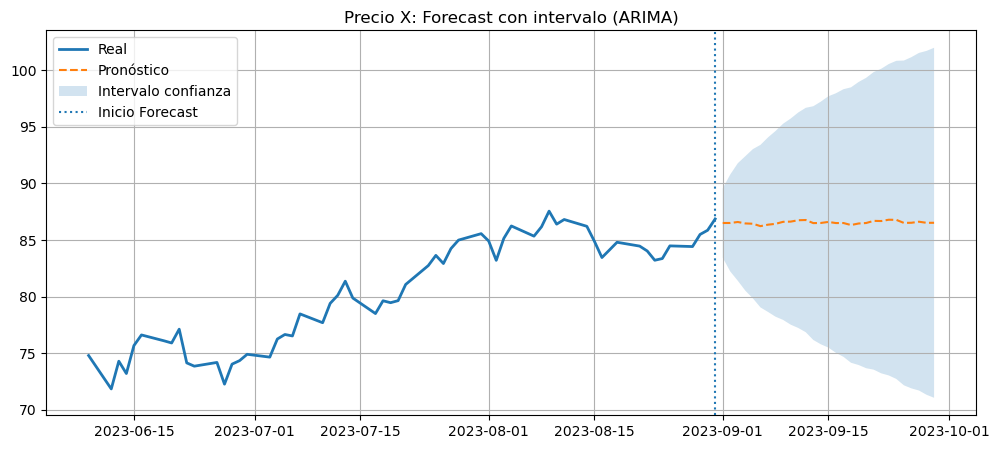

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Real
plt.plot(df.reset_index()["Date"].iloc[-60:], 
         df["Price_X"].iloc[-60:], 
         label="Real", linewidth=2)

# Forecast
plt.plot(df_x_forecast["Date"], 
         df_x_forecast["X_mean"], 
         linestyle="--", label="Pronóstico")

# Intervalo
plt.fill_between(df_x_forecast["Date"],
                 df_x_forecast["X_lower"],
                 df_x_forecast["X_upper"],
                 alpha=0.2, label="Intervalo confianza")

# Línea de corte
plt.axvline(x=df.reset_index()["Date"].iloc[-1], linestyle=":", label="Inicio Forecast")

plt.title("Precio X: Forecast con intervalo (ARIMA)")
plt.legend()
plt.grid()

plt.show()

### Pronostico Price Z

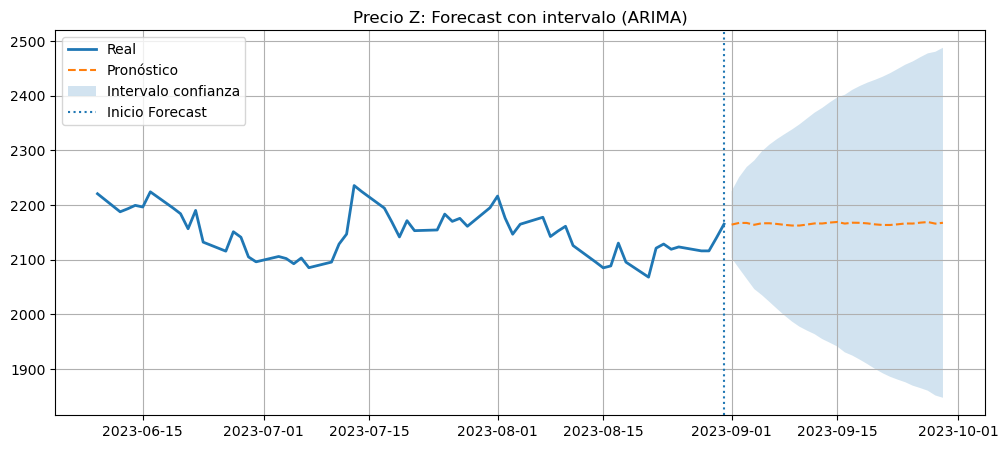

In [113]:
plt.figure(figsize=(12,5))

# Real
plt.plot(df.reset_index()["Date"].iloc[-60:], 
         df["Price_Z"].iloc[-60:], 
         label="Real", linewidth=2)

# Forecast
plt.plot(df_z_forecast["Date"], 
         df_z_forecast["Z_mean"], 
         linestyle="--", label="Pronóstico")

# Intervalo
plt.fill_between(df_z_forecast["Date"],
                 df_z_forecast["Z_lower"],
                 df_z_forecast["Z_upper"],
                 alpha=0.2, label="Intervalo confianza")

# Línea de corte
plt.axvline(x=df.reset_index()["Date"].iloc[-1], linestyle=":", label="Inicio Forecast")

plt.title("Precio Z: Forecast con intervalo (ARIMA)")
plt.legend()
plt.grid()

plt.show()

In [114]:
pred_conso = pred_x_conso.rename(columns={"predicted_mean": "Price_X"})[["Date","Price_X"]].merge(
    pred_z_conso.rename(columns={"predicted_mean": "Price_Z"})[["Date","Price_Z"]],  on = "Date", how = "left"
)

In [115]:
pred_conso

,Date,Price_X,Price_Z
0,2023-09-01,86.502163,2164.256648
1,2023-09-02,86.503417,2167.420848
2,2023-09-03,86.590910,2167.368206
3,2023-09-04,86.463308,2163.956558
4,2023-09-05,86.436772,2166.770162
5,2023-09-06,86.224095,2166.772924
6,2023-09-07,86.354412,2165.521268
7,2023-09-08,86.427628,2163.887930
8,2023-09-09,86.605362,2162.618418
9,2023-09-10,86.624109,2162.618968


In [116]:
df_real_fsct = pd.concat([equipos.reset_index(drop = True),pred_conso
],axis = 0).drop(["Price_Y","Price_Equipo1","Price_Equipo2"], axis = 1)

In [117]:
df_real_fsct["Date"] = pd.to_datetime(df_real_fsct["Date"])

In [118]:
df_real_fsct

,Date,Price_X,Price_Z
0,2010-01-04,80.120000,2225.250000
1,2010-01-05,80.590000,2246.500000
2,2010-01-06,81.890000,2302.500000
3,2010-01-07,81.510000,2306.500000
4,2010-01-08,81.370000,2261.250000
...,...,...,...
25,2023-09-26,86.522262,2167.889058
26,2023-09-27,86.615277,2169.005233
27,2023-09-28,86.516738,2166.093484
28,2023-09-29,86.521329,2167.657576


#### Promedio Movil

In [119]:
df_real_fsct["X_prom_3"] = df_real_fsct["Price_X"].rolling(window=3).mean()
df_real_fsct["Z_prom_3"] = df_real_fsct["Price_Z"].rolling(window=3).mean()
df_real_fsct["X_prom_6"] = df_real_fsct["Price_X"].rolling(window=6).mean()
df_real_fsct["Z_prom_6"] = df_real_fsct["Price_Z"].rolling(window=6).mean()
df_real_fsct["X_prom_9"] = df_real_fsct["Price_X"].rolling(window=9).mean()
df_real_fsct["Z_prom_9"] = df_real_fsct["Price_Z"].rolling(window=9).mean()
df_real_fsct["X_prom_12"] = df_real_fsct["Price_X"].rolling(window=12).mean()
df_real_fsct["Z_prom_12"] = df_real_fsct["Price_Z"].rolling(window=12).mean()
df_real_fsct["X_prom_15"] = df_real_fsct["Price_X"].rolling(window=15).mean()
df_real_fsct["Z_prom_15"] = df_real_fsct["Price_Z"].rolling(window=15).mean()
df_real_fsct["X_prom_30"] = df_real_fsct["Price_X"].rolling(window=30).mean()
df_real_fsct["Z_prom_30"] = df_real_fsct["Price_Z"].rolling(window=30).mean()

In [120]:
df_real_fsct

,Date,Price_X,Price_Z,X_prom_3,Z_prom_3,X_prom_6,Z_prom_6,X_prom_9,Z_prom_9,X_prom_12,Z_prom_12,X_prom_15,Z_prom_15,X_prom_30,Z_prom_30
0,2010-01-04,80.120000,2225.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,80.590000,2246.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,81.890000,2302.500000,80.866667,2258.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,81.510000,2306.500000,81.330000,2285.166667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,81.370000,2261.250000,81.590000,2290.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,2023-09-26,86.522262,2167.889058,86.603105,2166.834553,86.661015,2165.439279,86.582684,2165.723435,86.569729,2166.219051,86.573419,2166.368063,86.423641,2161.636809
26,2023-09-27,86.615277,2169.005233,86.548970,2167.711266,86.648394,2166.332872,86.615481,2165.882753,86.571279,2166.209187,86.563344,2166.534646,86.496817,2163.395316
27,2023-09-28,86.516738,2166.093484,86.551426,2167.662592,86.621987,2166.741477,86.621985,2165.832205,86.572969,2166.200359,86.564900,2166.517601,86.531041,2165.056766
28,2023-09-29,86.521329,2167.657576,86.551115,2167.585431,86.577110,2167.209992,86.624381,2166.154663,86.574791,2166.188934,86.566006,2166.492327,86.553086,2165.970352


#### Precios Rezagados

In [121]:
# Lags reales (valores pasados)
df_real_fsct["X_lag_1"] = df_real_fsct["Price_X"].shift(1)
df_real_fsct["X_lag_3"] = df_real_fsct["Price_X"].shift(3)
df_real_fsct["X_lag_6"] = df_real_fsct["Price_X"].shift(6)
df_real_fsct["X_lag_12"] = df_real_fsct["Price_X"].shift(12)
df_real_fsct["X_lag_15"] = df_real_fsct["Price_X"].shift(15)
df_real_fsct["X_lag_30"] = df_real_fsct["Price_X"].shift(30)
df_real_fsct["Z_lag_1"] = df_real_fsct["Price_Z"].shift(1)
df_real_fsct["Z_lag_3"] = df_real_fsct["Price_Z"].shift(3)
df_real_fsct["Z_lag_6"] = df_real_fsct["Price_Z"].shift(6)
df_real_fsct["Z_lag_12"] = df_real_fsct["Price_Z"].shift(12)
df_real_fsct["Z_lag_15"] = df_real_fsct["Price_Z"].shift(15)
df_real_fsct["Z_lag_30"] = df_real_fsct["Price_Z"].shift(30)

In [122]:
df_real_fsct = df_real_fsct.reset_index(drop=True)

In [123]:
df_real_fsct

,Date,Price_X,Price_Z,X_prom_3,Z_prom_3,X_prom_6,Z_prom_6,X_prom_9,Z_prom_9,X_prom_12,...,X_lag_6,X_lag_12,X_lag_15,X_lag_30,Z_lag_1,Z_lag_3,Z_lag_6,Z_lag_12,Z_lag_15,Z_lag_30
0,2010-01-04,80.120000,2225.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,80.590000,2246.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2225.250000,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,81.890000,2302.500000,80.866667,2258.083333,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2246.500000,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,81.510000,2306.500000,81.330000,2285.166667,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2302.500000,2225.250000,NaN,NaN,NaN,NaN
4,2010-01-08,81.370000,2261.250000,81.590000,2290.083333,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2306.500000,2246.500000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3555,2023-09-26,86.522262,2167.889058,86.603105,2166.834553,86.661015,2165.439279,86.582684,2165.723435,86.569729,...,86.499764,86.504732,86.745775,84.48,2166.239508,2164.846485,2164.755450,2168.036684,2164.391392,2123.50
3556,2023-09-27,86.615277,2169.005233,86.548970,2167.711266,86.648394,2166.332872,86.615481,2165.882753,86.571279,...,86.690998,86.596679,86.766390,84.42,2167.889058,2166.375094,2163.643674,2169.123602,2166.506477,2116.25
3557,2023-09-28,86.516738,2166.093484,86.551426,2167.662592,86.621987,2166.741477,86.621985,2165.832205,86.572969,...,86.675182,86.496459,86.493406,85.49,2169.005233,2166.239508,2163.641854,2166.199417,2166.349166,2116.25
3558,2023-09-29,86.521329,2167.657576,86.551115,2167.585431,86.577110,2167.209992,86.624381,2166.154663,86.574791,...,86.790590,86.499458,86.504732,85.86,2166.093484,2167.889058,2164.846485,2167.794676,2168.036684,2140.25


In [124]:
df_feat_fsct = df_real_fsct[df_real_fsct["Date"] > pd.Timestamp(last_date) ]

In [125]:
df_feat_fsct

,Date,Price_X,Price_Z,X_prom_3,Z_prom_3,X_prom_6,Z_prom_6,X_prom_9,Z_prom_9,X_prom_12,...,X_lag_6,X_lag_12,X_lag_15,X_lag_30,Z_lag_1,Z_lag_3,Z_lag_6,Z_lag_12,Z_lag_15,Z_lag_30
3530,2023-09-01,86.502163,2164.256648,86.407388,2156.585549,85.602027,2137.626108,84.912463,2132.778516,84.799347,...,83.360000,83.450000,86.810000,81.07,2165.250000,2116.250000,2119.250000,2088.750000,2126.000000,2153.25
3531,2023-09-02,86.503417,2167.420848,86.621860,2165.642498,85.939263,2144.946249,85.187287,2137.908611,84.997965,...,84.480000,84.120000,86.210000,82.74,2164.256648,2140.250000,2123.500000,2130.500000,2095.750000,2154.50
3532,2023-09-03,86.590910,2167.368206,86.532163,2166.348567,86.301082,2153.465950,85.562943,2142.199522,85.147207,...,84.420000,84.800000,84.890000,83.64,2167.420848,2165.250000,2116.250000,2095.750000,2085.250000,2183.50
3533,2023-09-04,86.463308,2163.956558,86.519212,2166.248537,86.463300,2161.417043,85.907755,2147.166918,85.314150,...,85.490000,84.460000,83.450000,82.92,2167.368206,2164.256648,2116.250000,2068.250000,2088.750000,2170.25
3534,2023-09-05,86.436772,2166.770162,86.496997,2166.031642,86.559428,2165.837070,86.125174,2151.974713,85.514714,...,85.860000,84.030000,84.120000,84.24,2163.956558,2167.420848,2140.250000,2121.250000,2130.500000,2175.75
3535,2023-09-06,86.224095,2166.772924,86.374725,2165.833214,86.453444,2166.090891,86.325629,2157.588372,85.765889,...,86.860000,83.210000,84.800000,84.99,2166.770162,2167.368206,2165.250000,2128.750000,2095.750000,2161.25
3536,2023-09-07,86.354412,2165.521268,86.338426,2166.354784,86.428819,2166.301661,86.421675,2163.062957,86.015423,...,86.502163,83.360000,84.460000,85.56,2166.772924,2163.956558,2164.256648,2119.250000,2068.250000,2195.25
3537,2023-09-08,86.427628,2163.887930,86.335378,2165.394040,86.416188,2165.712841,86.484745,2165.689394,86.177725,...,86.503417,84.480000,84.030000,84.91,2165.521268,2166.770162,2167.420848,2123.500000,2121.250000,2216.50
3538,2023-09-09,86.605362,2162.618418,86.462467,2164.009205,86.418596,2164.921210,86.456452,2165.396996,86.359839,...,86.590910,84.420000,83.210000,83.20,2163.887930,2166.772924,2167.368206,2116.250000,2128.750000,2176.25
3539,2023-09-10,86.624109,2162.618968,86.552366,2163.041772,86.445396,2164.698278,86.470001,2165.215031,86.454348,...,86.463308,85.490000,83.360000,85.14,2162.618418,2165.521268,2163.956558,2116.250000,2119.250000,2146.75


### Pronostico Equipo 1 y Equipo 2 

Se realiza el pronostico de los equipos 1 y 2 con el modelo previamente entrenado

In [128]:
df_pred_F = pd.DataFrame({
    "Date": df_feat_fsct["Date"],
    "Price_Equipo1_pred": model1_final.predict(df_feat_fsct.drop("Date", axis=1)),
    "Price_Equipo2_pred": model2_final.predict(df_feat_fsct.drop("Date", axis=1))
})

In [129]:
df_pred_F

,Date,Price_Equipo1_pred,Price_Equipo2_pred
3530,2023-09-01,468.931335,954.877869
3531,2023-09-02,470.946045,933.095398
3532,2023-09-03,472.459564,933.094055
3533,2023-09-04,465.399811,931.915100
3534,2023-09-05,465.087189,934.483276
3535,2023-09-06,491.099792,933.500671
3536,2023-09-07,487.210785,928.940735
3537,2023-09-08,489.326447,928.558594
3538,2023-09-09,483.367249,928.465515
3539,2023-09-10,486.009888,926.782410


In [130]:
df.reset_index()

,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2,X_diff,Z_diff,X_prom_3,Z_prom_3,...,X_lag_6,X_lag_12,X_lag_15,X_lag_30,Z_lag_1,Z_lag_3,Z_lag_6,Z_lag_12,Z_lag_15,Z_lag_30
0,2010-01-04,80.12,527.50,2225.25,434.73,931.73,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,80.59,527.50,2246.50,449.97,968.56,0.47,21.25,NaN,NaN,...,NaN,NaN,NaN,NaN,2225.25,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,81.89,527.50,2302.50,444.48,960.51,1.30,56.00,80.866667,2258.083333,...,NaN,NaN,NaN,NaN,2246.50,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,81.51,527.50,2306.50,440.90,960.14,-0.38,4.00,81.330000,2285.166667,...,NaN,NaN,NaN,NaN,2302.50,2225.25,NaN,NaN,NaN,NaN
4,2010-01-08,81.37,552.50,2261.25,448.82,949.55,-0.14,-45.25,81.590000,2290.083333,...,NaN,NaN,NaN,NaN,2306.50,2246.50,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3525,2023-08-25,84.48,554.00,2123.50,450.36,899.65,1.12,4.25,83.683333,2123.833333,...,84.12,87.55,86.24,79.87,2119.25,2121.25,2130.50,2152.50,2165.00,2224.75
3526,2023-08-28,84.42,549.00,2116.25,469.03,933.20,-0.06,-7.25,84.086667,2119.666667,...,84.80,86.40,85.34,78.50,2123.50,2128.75,2095.75,2161.25,2177.75,2194.50
3527,2023-08-29,85.49,545.33,2116.25,460.42,901.79,1.07,0.00,84.796667,2118.666667,...,84.46,86.81,86.17,79.63,2116.25,2119.25,2068.25,2126.00,2142.50,2169.00
3528,2023-08-30,85.86,543.67,2140.25,464.80,945.40,0.37,24.00,85.256667,2124.250000,...,84.03,86.21,87.55,79.46,2116.25,2123.50,2121.25,2095.75,2152.50,2141.75


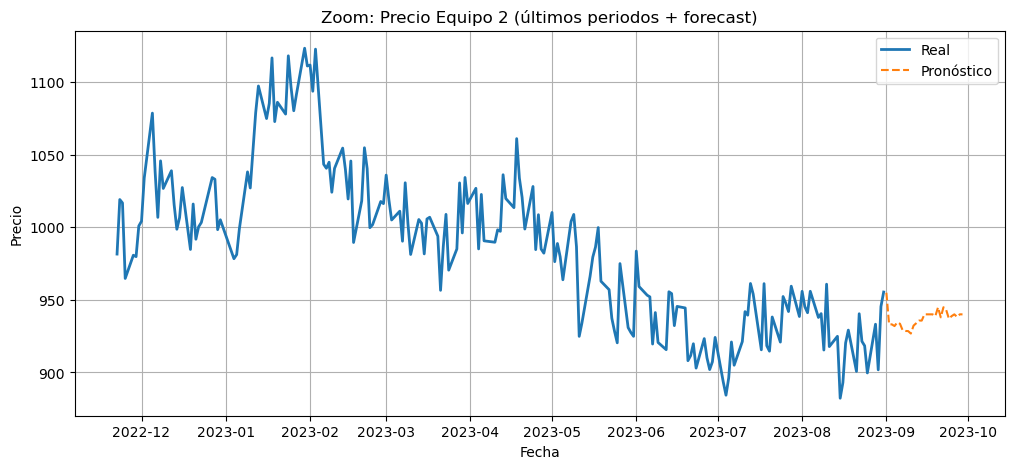

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Últimos 200 puntos históricos
plt.plot(df.reset_index()["Date"].iloc[-200:], df["Price_Equipo2"].iloc[-200:], 
         label="Real", linewidth=2)

# Forecast
plt.plot(df_pred_F["Date"], df_pred_F["Price_Equipo2_pred"], 
         label="Pronóstico", linestyle="--")

plt.title("Zoom: Precio Equipo 2 (últimos periodos + forecast)")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid()

plt.show()

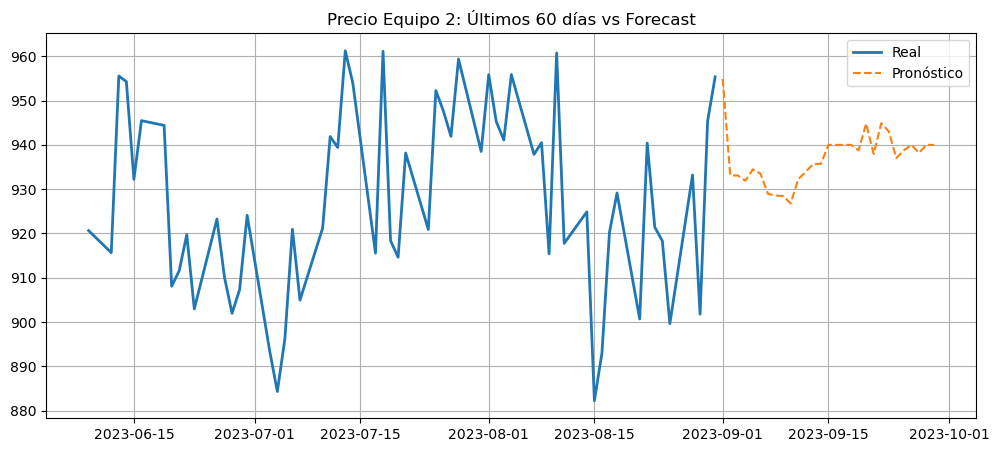

In [132]:
plt.figure(figsize=(12,5))

# Últimos 60 días
plt.plot(df.reset_index()["Date"].iloc[-60:], df["Price_Equipo2"].iloc[-60:], 
         label="Real", linewidth=2)

# Forecast
plt.plot(df_pred_F["Date"], df_pred_F["Price_Equipo2_pred"], 
         label="Pronóstico", linestyle="--")

plt.title("Precio Equipo 2: Últimos 60 días vs Forecast")
plt.legend()
plt.grid()

plt.show()

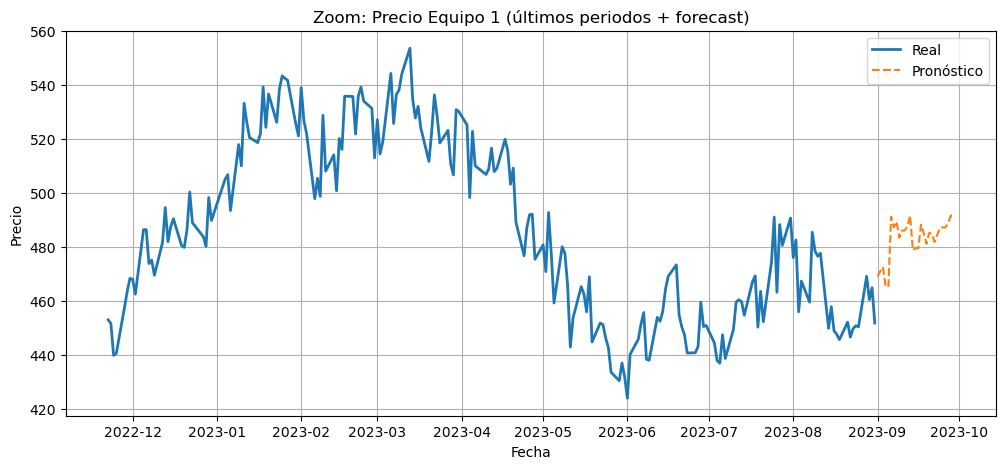

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Últimos 200 puntos históricos
plt.plot(df.reset_index()["Date"].iloc[-200:], df["Price_Equipo1"].iloc[-200:], 
         label="Real", linewidth=2)

# Forecast
plt.plot(df_pred_F["Date"], df_pred_F["Price_Equipo1_pred"], 
         label="Pronóstico", linestyle="--")

plt.title("Zoom: Precio Equipo 1 (últimos periodos + forecast)")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid()

plt.show()

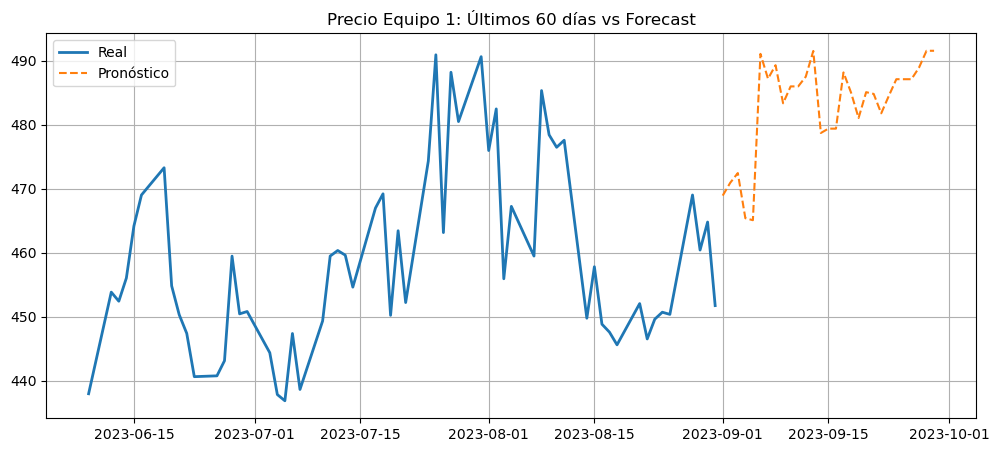

In [134]:
plt.figure(figsize=(12,5))

# Últimos 60 días
plt.plot(df.reset_index()["Date"].iloc[-60:], df["Price_Equipo1"].iloc[-60:], 
         label="Real", linewidth=2)

# Forecast
plt.plot(df_pred_F["Date"], df_pred_F["Price_Equipo1_pred"], 
         label="Pronóstico", linestyle="--")

plt.title("Precio Equipo 1: Últimos 60 días vs Forecast")
plt.legend()
plt.grid()

plt.show()

#### Pronostico de los Intervalos

Se proyectan los intervalos Lower y Upper para que el usuario tenga un rango para estimar como se puede mover los precios de los equipos 1 y 2

In [135]:
# LOWER
pred_conso_lower = pred_x_conso.rename(columns={"lower Price_X": "Price_X"})[["Date","Price_X"]].merge(
    pred_z_conso.rename(columns={"lower Price_Z": "Price_Z"})[["Date","Price_Z"]],
    on="Date", how="left"
)

# UPPER
pred_conso_upper = pred_x_conso.rename(columns={"upper Price_X": "Price_X"})[["Date","Price_X"]].merge(
    pred_z_conso.rename(columns={"upper Price_Z": "Price_Z"})[["Date","Price_Z"]],
    on="Date", how="left"
)

In [136]:
def crear_features(df_base):
    df_temp = df_base.copy()

    # Promedios móviles
    for w in [3,6,9,12,15,30]:
        df_temp[f"X_prom_{w}"] = df_temp["Price_X"].rolling(window=w).mean()
        df_temp[f"Z_prom_{w}"] = df_temp["Price_Z"].rolling(window=w).mean()

    # Lags
    for lag in [1,3,6,12,15,30]:
        df_temp[f"X_lag_{lag}"] = df_temp["Price_X"].shift(lag)
        df_temp[f"Z_lag_{lag}"] = df_temp["Price_Z"].shift(lag)

    return df_temp

In [137]:
# LOWER
df_lower = pd.concat([equipos.reset_index(drop=True), pred_conso_lower], axis=0)
df_lower = df_lower.drop(["Price_Y","Price_Equipo1","Price_Equipo2"], axis=1)
df_lower["Date"] = pd.to_datetime(df_lower["Date"])
df_lower = crear_features(df_lower).reset_index(drop=True)

# UPPER
df_upper = pd.concat([equipos.reset_index(drop=True), pred_conso_upper], axis=0)
df_upper = df_upper.drop(["Price_Y","Price_Equipo1","Price_Equipo2"], axis=1)
df_upper["Date"] = pd.to_datetime(df_upper["Date"])
df_upper = crear_features(df_upper).reset_index(drop=True)

In [138]:
df_lower_fsct = df_lower[df_lower["Date"] > pd.Timestamp(last_date)]
df_upper_fsct = df_upper[df_upper["Date"] > pd.Timestamp(last_date)]

In [139]:
df_lower_fsct

,Date,Price_X,Price_Z,X_prom_3,Z_prom_3,X_prom_6,Z_prom_6,X_prom_9,Z_prom_9,X_prom_12,...,X_lag_3,Z_lag_3,X_lag_6,Z_lag_6,X_lag_12,Z_lag_12,X_lag_15,Z_lag_15,X_lag_30,Z_lag_30
3530,2023-09-01,83.435610,2103.240578,85.385203,2136.246859,85.090935,2127.456763,84.571734,2125.998953,84.543801,...,85.490000,2116.250000,83.360000,2119.250000,83.450000,2088.750000,86.810000,2126.000000,81.07,2153.25
3531,2023-09-02,82.219386,2083.966230,84.171666,2117.485603,84.714166,2120.867801,84.370555,2121.856312,84.385416,...,85.860000,2140.250000,84.480000,2123.500000,84.120000,2130.500000,86.210000,2095.750000,82.74,2154.50
3532,2023-09-03,81.398040,2065.144857,82.351012,2084.117222,84.210506,2112.350278,84.169226,2114.789074,84.101920,...,86.860000,2165.250000,84.420000,2116.250000,84.800000,2095.750000,84.890000,2085.250000,83.64,2183.50
3533,2023-09-04,80.519488,2046.447312,81.378971,2065.186133,83.382087,2100.716496,83.853614,2106.699886,83.773544,...,83.435610,2103.240578,85.490000,2116.250000,84.460000,2068.250000,83.450000,2088.750000,82.92,2170.25
3534,2023-09-05,79.840891,2035.500289,80.586140,2049.030819,82.378903,2083.258211,83.338157,2096.922141,83.424451,...,82.219386,2083.966230,85.860000,2140.250000,84.030000,2121.250000,84.120000,2130.500000,84.24,2175.75
3535,2023-09-06,79.044770,2023.169723,79.801716,2035.039108,81.076364,2059.578165,82.740909,2086.579888,83.077349,...,81.398040,2065.144857,86.860000,2165.250000,83.210000,2128.750000,84.800000,2095.750000,84.99,2161.25
3536,2023-09-07,78.642404,2010.508190,79.176022,2023.059400,80.277496,2044.122767,81.980065,2074.830798,82.684216,...,80.519488,2046.447312,83.435610,2103.240578,83.360000,2119.250000,84.460000,2068.250000,85.56,2195.25
3537,2023-09-08,78.222221,1998.275592,78.636465,2010.651168,79.611302,2029.840994,81.131423,2059.055863,82.162734,...,79.840891,2035.500289,82.219386,2083.966230,84.480000,2123.500000,84.030000,2121.250000,84.91,2216.50
3538,2023-09-09,77.938004,1987.032679,78.267543,1998.605487,79.034630,2016.822297,80.140090,2039.253939,81.622568,...,79.044770,2023.169723,81.398040,2065.144857,84.420000,2116.250000,83.210000,2128.750000,83.20,2176.25
3539,2023-09-10,77.520657,1977.602920,77.893627,1987.637063,78.534824,2005.348232,79.482873,2025.294199,80.958456,...,78.642404,2010.508190,80.519488,2046.447312,85.490000,2116.250000,83.360000,2119.250000,85.14,2146.75


In [140]:
features_final = X_train.columns

In [141]:
# LOWER
X_lower = df_lower_fsct[features_final]

# UPPER
X_upper = df_upper_fsct[features_final]

In [142]:
df_pred_lower = pd.DataFrame({
    "Date": df_lower_fsct["Date"],
    "Equipo1_lower": model1_final.predict(X_lower),
    "Equipo2_lower": model2_final.predict(X_lower)
})

df_pred_upper = pd.DataFrame({
    "Date": df_upper_fsct["Date"],
    "Equipo1_upper": model1_final.predict(X_upper),
    "Equipo2_upper": model2_final.predict(X_upper)
})

In [143]:
df_final_pred = df_pred_F.merge(df_pred_lower, on="Date")
df_final_pred = df_final_pred.merge(df_pred_upper, on="Date")

df_final_pred

,Date,Price_Equipo1_pred,Price_Equipo2_pred,Equipo1_lower,Equipo2_lower,Equipo1_upper,Equipo2_upper
0,2023-09-01,468.931335,954.877869,466.763184,918.050598,469.002014,966.994873
1,2023-09-02,470.946045,933.095398,477.179932,910.037109,485.315277,970.084656
2,2023-09-03,472.459564,933.094055,480.101288,901.448181,489.327362,976.651550
3,2023-09-04,465.399811,931.915100,472.938568,904.212769,486.072571,998.420349
4,2023-09-05,465.087189,934.483276,472.752411,912.087280,494.035797,1011.245483
5,2023-09-06,491.099792,933.500671,479.904083,884.787598,502.713715,1015.519226
6,2023-09-07,487.210785,928.940735,472.370758,891.173889,503.285919,996.686401
7,2023-09-08,489.326447,928.558594,485.661591,879.899231,500.104187,1004.611694
8,2023-09-09,483.367249,928.465515,493.405670,871.387573,499.077271,1006.182068
9,2023-09-10,486.009888,926.782410,497.467010,867.988708,500.813599,999.302856


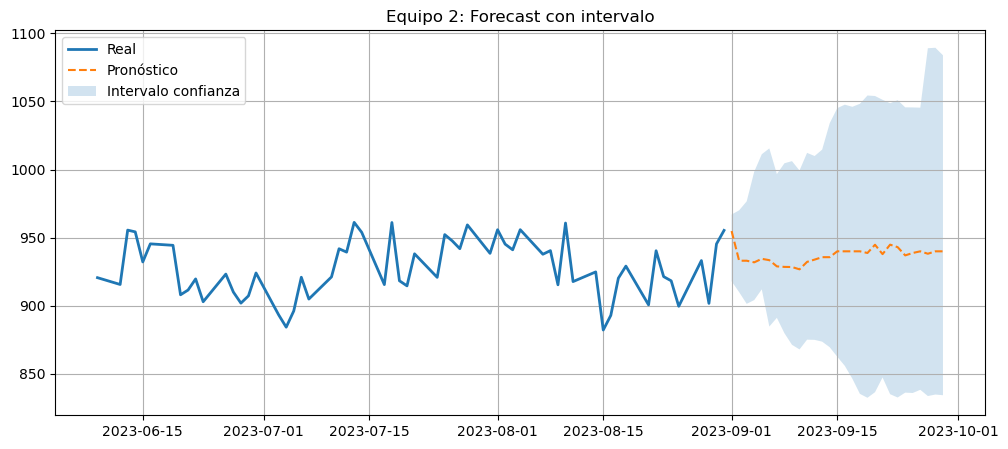

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Real
plt.plot(df.reset_index()["Date"].iloc[-60:], 
         df["Price_Equipo2"].iloc[-60:], 
         label="Real", linewidth=2)

# Pronóstico medio
plt.plot(df_final_pred["Date"], 
         df_final_pred["Price_Equipo2_pred"], 
         linestyle="--", label="Pronóstico")

# Intervalo
plt.fill_between(df_final_pred["Date"],
                 df_final_pred["Equipo2_lower"],
                 df_final_pred["Equipo2_upper"],
                 alpha=0.2, label="Intervalo confianza")

plt.title("Equipo 2: Forecast con intervalo")
plt.legend()
plt.grid()

plt.show()

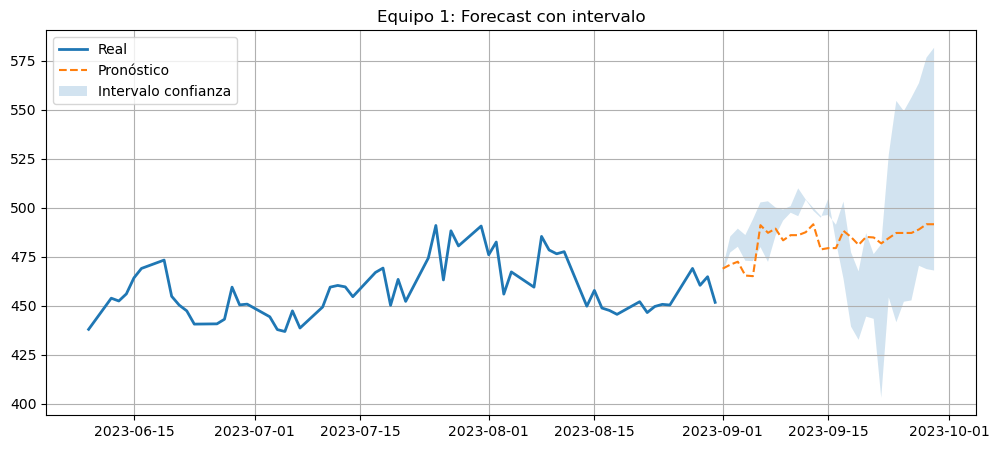

In [145]:
plt.figure(figsize=(12,5))

plt.plot(df.reset_index()["Date"].iloc[-60:], 
         df["Price_Equipo1"].iloc[-60:], 
         label="Real", linewidth=2)

plt.plot(df_final_pred["Date"], 
         df_final_pred["Price_Equipo1_pred"], 
         linestyle="--", label="Pronóstico")

plt.fill_between(df_final_pred["Date"],
                 df_final_pred["Equipo1_lower"],
                 df_final_pred["Equipo1_upper"],
                 alpha=0.2, label="Intervalo confianza")

plt.title("Equipo 1: Forecast con intervalo")
plt.legend()
plt.grid()

plt.show()

Suavizamos los intervalos para reducir la incertidumbre

In [146]:
# Suavizar intervalos
df_final_pred["Equipo2_lower_smooth"] = df_final_pred["Equipo2_lower"].rolling(3).mean()
df_final_pred["Equipo2_upper_smooth"] = df_final_pred["Equipo2_upper"].rolling(3).mean()

df_final_pred["Equipo1_lower_smooth"] = df_final_pred["Equipo1_lower"].rolling(3).mean()
df_final_pred["Equipo1_upper_smooth"] = df_final_pred["Equipo1_upper"].rolling(3).mean()

In [148]:
df_final_pred

,Date,Price_Equipo1_pred,Price_Equipo2_pred,Equipo1_lower,Equipo2_lower,Equipo1_upper,Equipo2_upper,Equipo2_lower_smooth,Equipo2_upper_smooth,Equipo1_lower_smooth,Equipo1_upper_smooth
0,2023-09-01,468.931335,954.877869,466.763184,918.050598,469.002014,966.994873,NaN,NaN,NaN,NaN
1,2023-09-02,470.946045,933.095398,477.179932,910.037109,485.315277,970.084656,NaN,NaN,NaN,NaN
2,2023-09-03,472.459564,933.094055,480.101288,901.448181,489.327362,976.651550,909.845296,971.243693,474.681468,481.214884
3,2023-09-04,465.399811,931.915100,472.938568,904.212769,486.072571,998.420349,905.232686,981.718852,476.739929,486.905070
4,2023-09-05,465.087189,934.483276,472.752411,912.087280,494.035797,1011.245483,905.916077,995.439128,475.264089,489.811910
5,2023-09-06,491.099792,933.500671,479.904083,884.787598,502.713715,1015.519226,900.362549,1008.395020,475.198354,494.274028
6,2023-09-07,487.210785,928.940735,472.370758,891.173889,503.285919,996.686401,896.016256,1007.817037,475.009084,500.011810
7,2023-09-08,489.326447,928.558594,485.661591,879.899231,500.104187,1004.611694,885.286906,1005.605774,479.312144,502.034607
8,2023-09-09,483.367249,928.465515,493.405670,871.387573,499.077271,1006.182068,880.820231,1002.493388,483.812673,500.822459
9,2023-09-10,486.009888,926.782410,497.467010,867.988708,500.813599,999.302856,873.091838,1003.365540,492.178090,499.998352


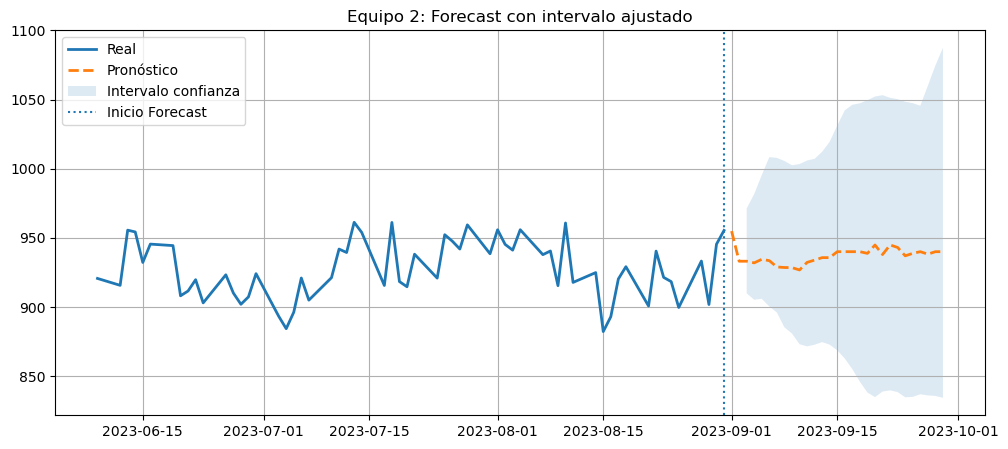

In [149]:
plt.figure(figsize=(12,5))

# Real
plt.plot(df.reset_index()["Date"].iloc[-60:], 
         df["Price_Equipo2"].iloc[-60:], 
         label="Real", linewidth=2)

# Forecast
plt.plot(df_final_pred["Date"], 
         df_final_pred["Price_Equipo2_pred"], 
         linestyle="--", linewidth=2, label="Pronóstico")

# Intervalo limpio
plt.fill_between(df_final_pred["Date"],
                 df_final_pred["Equipo2_lower_smooth"],
                 df_final_pred["Equipo2_upper_smooth"],
                 alpha=0.15, label="Intervalo confianza")

plt.axvline(x=df.reset_index()["Date"].iloc[-1], linestyle=":", label="Inicio Forecast")

plt.title("Equipo 2: Forecast con intervalo ajustado")
plt.legend()
plt.grid()

plt.show()

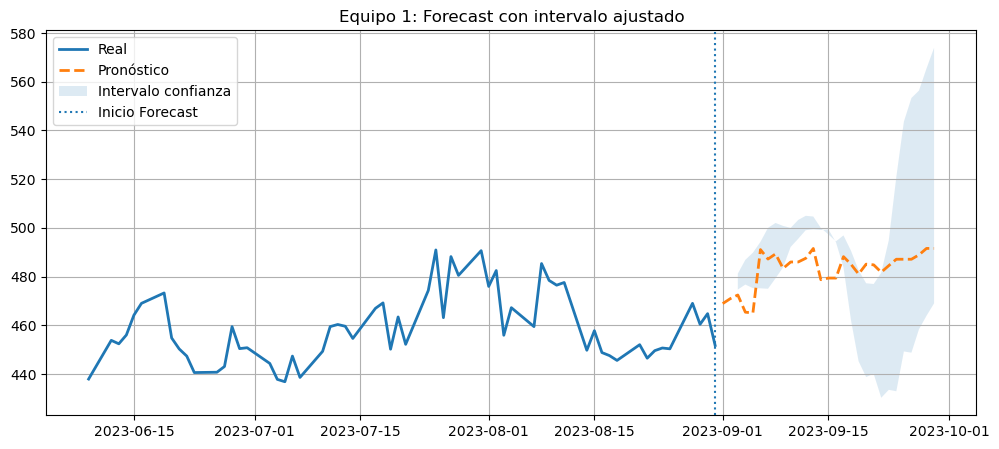

In [150]:
plt.figure(figsize=(12,5))

plt.plot(df.reset_index()["Date"].iloc[-60:], 
         df["Price_Equipo1"].iloc[-60:], 
         label="Real", linewidth=2)

plt.plot(df_final_pred["Date"], 
         df_final_pred["Price_Equipo1_pred"], 
         linestyle="--", linewidth=2, label="Pronóstico")

plt.fill_between(df_final_pred["Date"],
                 df_final_pred["Equipo1_lower_smooth"],
                 df_final_pred["Equipo1_upper_smooth"],
                 alpha=0.15, label="Intervalo confianza")

plt.axvline(x=df.reset_index()["Date"].iloc[-1], linestyle=":", label="Inicio Forecast")

plt.title("Equipo 1: Forecast con intervalo ajustado")
plt.legend()
plt.grid()

plt.show()

In [151]:
df_final_pred[["Date","Price_Equipo1_pred","Equipo1_upper","Equipo1_lower"]]

,Date,Price_Equipo1_pred,Equipo1_upper,Equipo1_lower
0,2023-09-01,468.931335,469.002014,466.763184
1,2023-09-02,470.946045,485.315277,477.179932
2,2023-09-03,472.459564,489.327362,480.101288
3,2023-09-04,465.399811,486.072571,472.938568
4,2023-09-05,465.087189,494.035797,472.752411
5,2023-09-06,491.099792,502.713715,479.904083
6,2023-09-07,487.210785,503.285919,472.370758
7,2023-09-08,489.326447,500.104187,485.661591
8,2023-09-09,483.367249,499.077271,493.405670
9,2023-09-10,486.009888,500.813599,497.467010


* Se realizó el pronóstico de los precios de los equipos 1 y 2 utilizando un modelo XGBoost. Previamente, se proyectaron las variables exógenas para alimentar el modelo, permitiendo generar no solo una estimación puntual, sino también intervalos de confianza (upper y lower), con el fin de brindar al usuario un rango probable en el que se puede ubicar el precio final.
* El horizonte de predicción se estableció en 30 días, considerando que, a medida que aumenta el periodo de pronóstico, también lo hace la incertidumbre. Aunque el modelo tiene la capacidad de proyectar a plazos más largos, desde una perspectiva estadística es más confiable trabajar con horizontes más acotados.
* Adicionalmente, se desarrolló un agente capaz de generar predicciones para distintos horizontes de tiempo según se requiera, acompañado de su respectivo análisis e interpretación. Este agente sigue la lógica del modelo propuesto e incorpora, a nivel contextual, factores macroeconómicos y eventos relevantes (como noticias), con el objetivo de enriquecer la lectura de los resultados.